##Installing Libraries

In [ ]:
!pip install transformers datasets accelerate evaluate -qqq
!pip install optuna

##Importing all Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from collections import Counter
from wordcloud import WordCloud
import re
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support, roc_curve, roc_auc_score
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, LSTM, Bidirectional, GRU
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import torch
from datasets import Dataset
import os
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    BertTokenizerFast,
    BertForSequenceClassification
)
import time

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.utils import class_weight
import optuna
import joblib

##Loading Dataset

In [ ]:
df = pd.read_csv("/content/emails.csv")
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


##Performing Initial Data Analysis

In [ ]:
print("--- Initial Data Analysis ---")

# 1. Number of spam and ham messages
spam_ham_counts = df['spam'].value_counts()
print(f"\nSpam vs. Ham counts:\n{spam_ham_counts}")
print(f"Number of spam messages: {spam_ham_counts.get(1, 0)}")
print(f"Number of ham messages: {spam_ham_counts.get(0, 0)}")

# 2. Duplicate messages
duplicate_messages = df.duplicated().sum()
print(f"\nNumber of duplicate messages: {duplicate_messages}")

# 3. Missing values
missing_values = df.isnull().sum()
print(f"\nMissing values per column:\n{missing_values}")

# 4. Average message length
df['message_length'] = df['text'].apply(len)
average_message_length = df['message_length'].mean()
print(f"\nAverage message length: {average_message_length:.2f} characters")

--- Initial Data Analysis ---

Spam vs. Ham counts:
spam
0    4360
1    1368
Name: count, dtype: int64
Number of spam messages: 1368
Number of ham messages: 4360

Number of duplicate messages: 33

Missing values per column:
text    0
spam    0
dtype: int64

Average message length: 1556.77 characters


##Performing EDA

--- Professional EDA ---


/tmp/ipykernel_2175/3593438458.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='spam', data=df, palette='viridis')


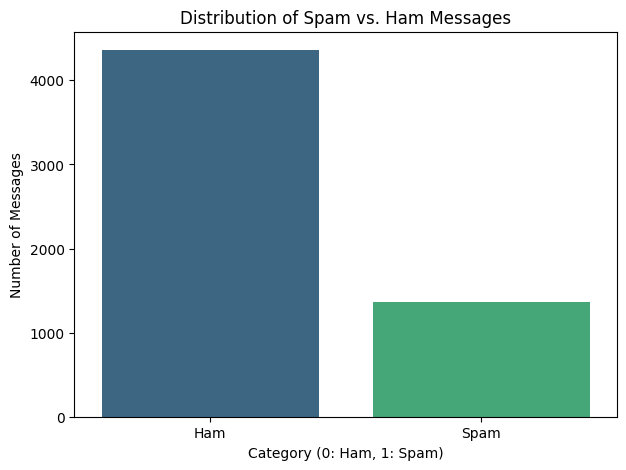

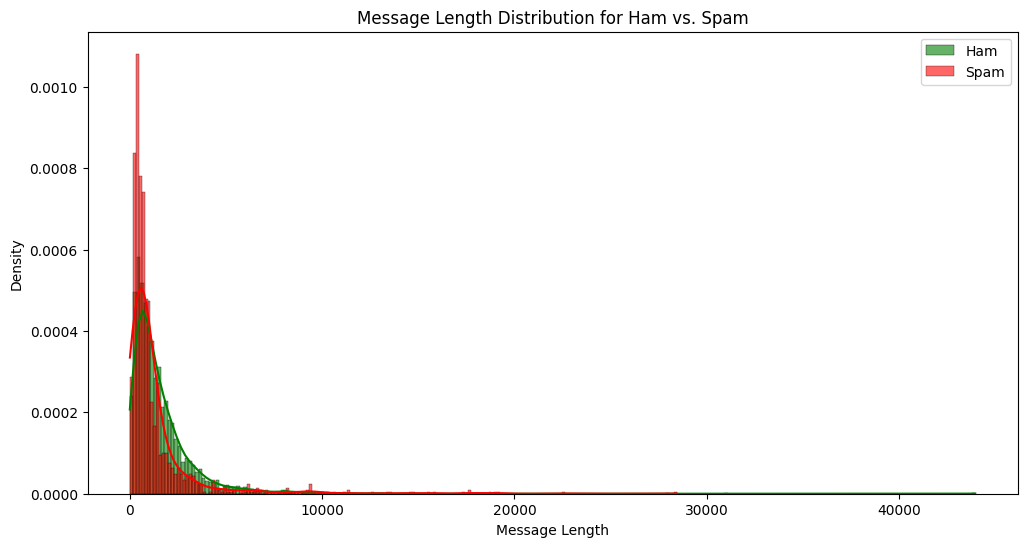


--- Word Clouds ---


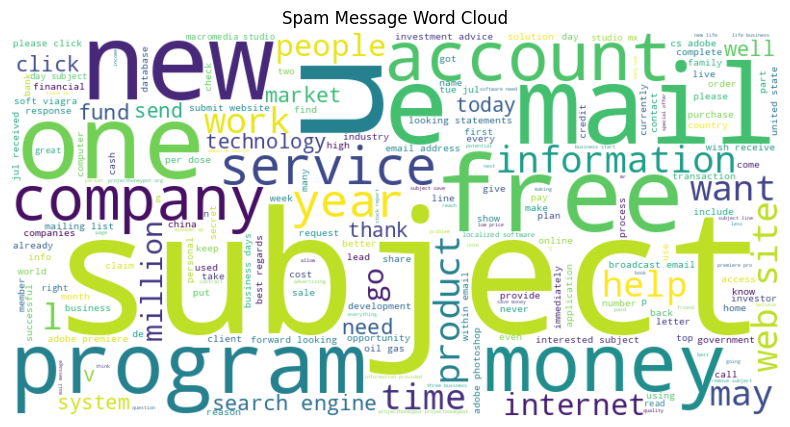

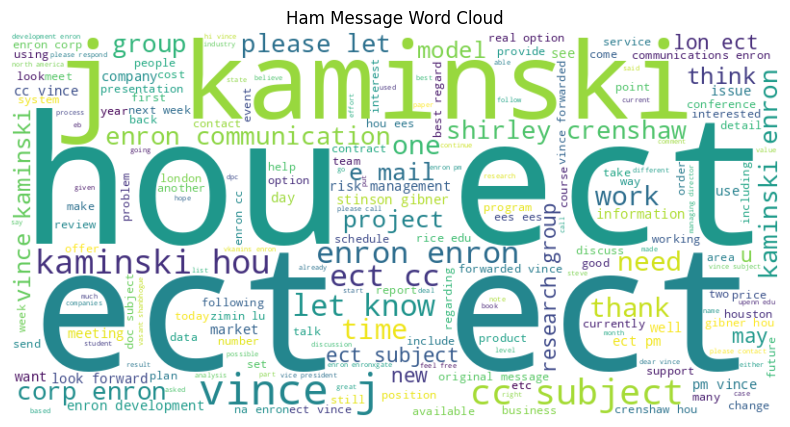


--- Top Spam Keywords (Unigrams) ---
'subject': 1574
'com': 998
'business': 844
'company': 805
'email': 804
'information': 740
'e': 698
'money': 662
'free': 606
'http': 600


/tmp/ipykernel_2175/3593438458.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[count for word, count in spam_keywords], y=[word for word, count in spam_keywords], palette='Reds_d')


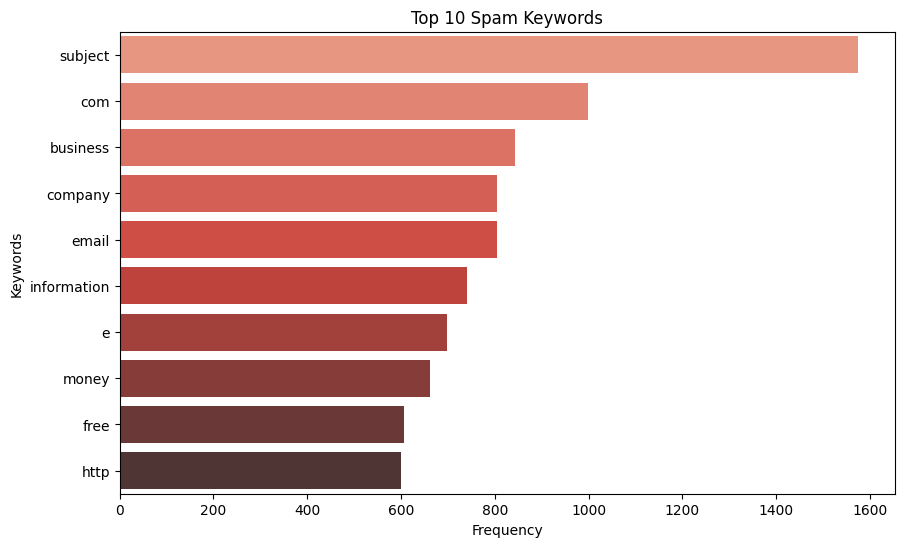


--- Top Ham Keywords (Unigrams) ---
'enron': 13382
'ect': 11417
'subject': 8605
'vince': 8531
'hou': 5569
'kaminski': 4770
'com': 4444
'please': 4386
'would': 4151
'cc': 3889


/tmp/ipykernel_2175/3593438458.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[count for word, count in ham_keywords], y=[word for word, count in ham_keywords], palette='Greens_d')


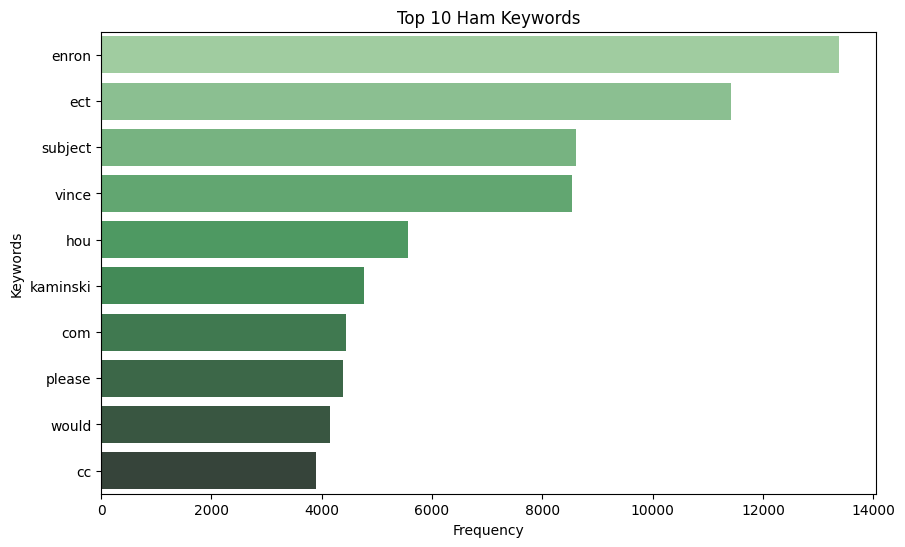


--- Bigram Analysis ---
Top 10 Spam Bigrams:
'e mail': 327
'http www': 309
'interested subject': 113
'forward looking': 112
'would like': 112
'mailing list': 112
'search engines': 111
'email address': 109
'submit website': 103
'looking statements': 101

Top 10 Ham Bigrams:
'hou ect': 5227
'ect ect': 4881
'j kaminski': 3331
'vince j': 3300
'enron com': 2244
'cc subject': 2062
'kaminski hou': 1778
'ect cc': 1582
'enron enron': 1547
'let know': 1436


/tmp/ipykernel_2175/3593438458.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[count for bigram, count in spam_bigrams], y=[' '.join(bigram) for bigram, count in spam_bigrams], palette='Reds_d')


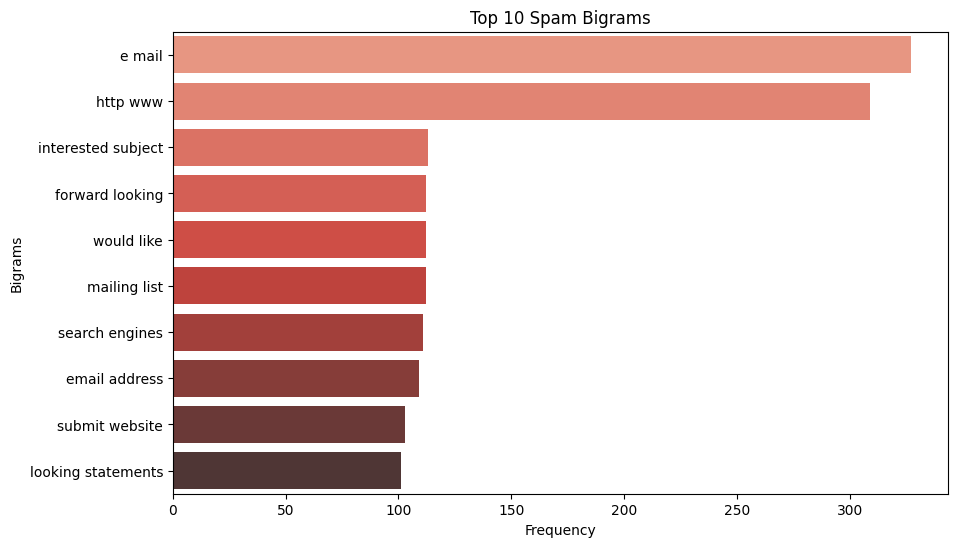

/tmp/ipykernel_2175/3593438458.py:127: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[count for bigram, count in ham_bigrams], y=[' '.join(bigram) for bigram, count in ham_bigrams], palette='Greens_d')


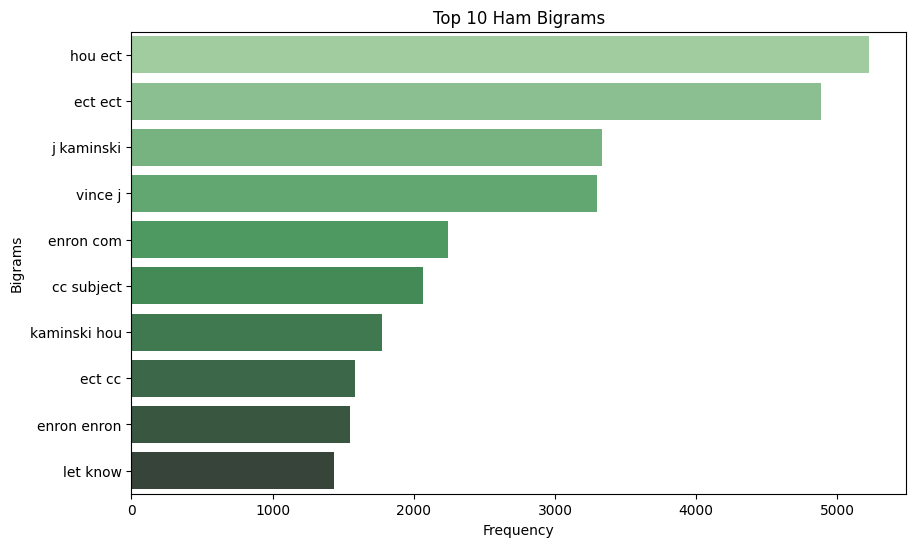


--- Trigram Analysis ---
Top 10 Spam Trigrams:
'forward looking statements': 100
'macromedia studio mx': 56
'projecthoneypot projecthoneypot org': 55
'adobe premiere pro': 54
'website search engines': 49
'three business days': 48
'e mail message': 47
'thinking breathing new': 45
'breathing new life': 45
'new life business': 45

Top 10 Ham Trigrams:
'hou ect ect': 4118
'vince j kaminski': 3294
'j kaminski hou': 1778
'kaminski hou ect': 1778
'ect ect cc': 1525
'please let know': 861
'ect cc subject': 856
'corp enron enron': 820
'kaminski enron com': 776
'j kaminski enron': 766


/tmp/ipykernel_2175/3593438458.py:148: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[count for trigram, count in spam_trigrams], y=[' '.join(trigram) for trigram, count in spam_trigrams], palette='Reds_d')


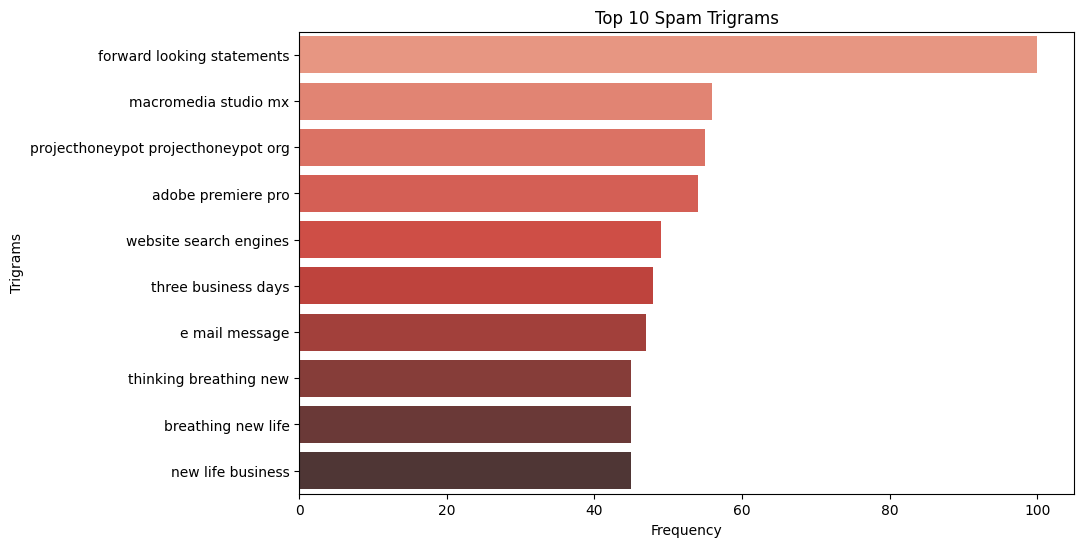

/tmp/ipykernel_2175/3593438458.py:156: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[count for trigram, count in ham_trigrams], y=[' '.join(trigram) for trigram, count in ham_trigrams], palette='Greens_d')


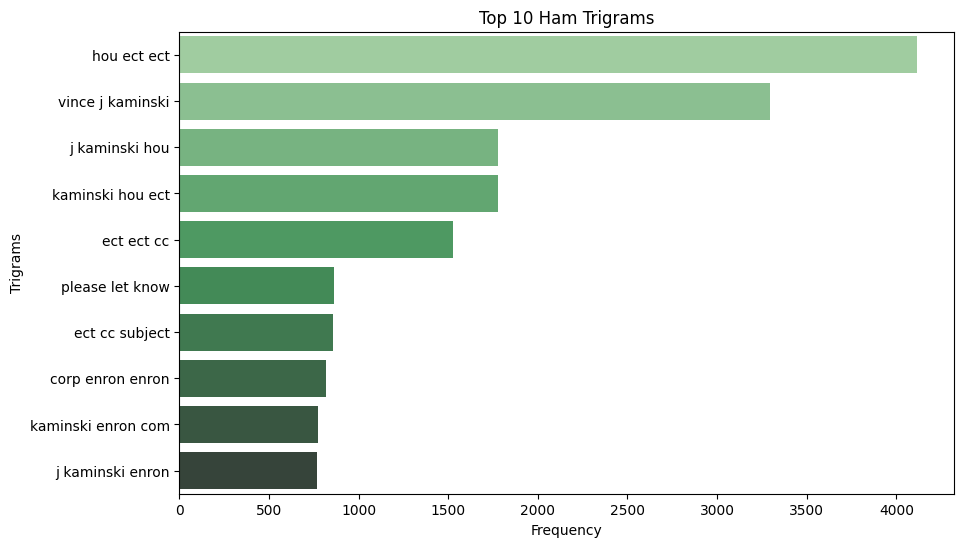

In [ ]:
# Download NLTK stopwords if not already downloaded
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower() # Convert to lowercase
    text = re.sub(r'[^a-z\s]', '', text) # Remove punctuation and numbers
    text = ' '.join([word for word in text.split() if word not in stop_words]) # Remove stopwords
    return text

df['cleaned_text'] = df['text'].apply(clean_text)


print("--- Professional EDA ---")

# Basic Visualizations

# 1. Spam vs Ham Countplot
plt.figure(figsize=(7, 5))
sns.countplot(x='spam', data=df, palette='viridis')
plt.title('Distribution of Spam vs. Ham Messages')
plt.xlabel('Category (0: Ham, 1: Spam)')
plt.ylabel('Number of Messages')
plt.xticks([0, 1], ['Ham', 'Spam'])
plt.show()

# 2. Message Length Distribution
plt.figure(figsize=(12, 6))
sns.histplot(df[df['spam'] == 0]['message_length'], color='green', label='Ham', kde=True, stat='density', alpha=0.6)
sns.histplot(df[df['spam'] == 1]['message_length'], color='red', label='Spam', kde=True, stat='density', alpha=0.6)
plt.title('Message Length Distribution for Ham vs. Spam')
plt.xlabel('Message Length')
plt.ylabel('Density')
plt.legend()
plt.show()

# Advanced Visualizations and Text Analysis

# Prepare text for word clouds and keyword analysis
spam_text = ' '.join(df[df['spam'] == 1]['cleaned_text'])
ham_text = ' '.join(df[df['spam'] == 0]['cleaned_text'])

# 3. Word Clouds
print("\n--- Word Clouds ---")

# Spam Word Cloud
plt.figure(figsize=(10, 5))
spam_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(spam_text)
plt.imshow(spam_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Spam Message Word Cloud')
plt.show()

# Ham Word Cloud
plt.figure(figsize=(10, 5))
ham_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(ham_text)
plt.imshow(ham_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Ham Message Word Cloud')
plt.show()

# Tokenize for keyword and N-gram analysis
spam_tokens = spam_text.split()
ham_tokens = ham_text.split()

# Function to get N-grams
def get_ngrams(tokens, n):
    n_grams = Counter(nltk.ngrams(tokens, n))
    return n_grams.most_common(10) # Get top 10

# 4. Top Spam Keywords
print("\n--- Top Spam Keywords (Unigrams) ---")
spam_keywords = Counter(spam_tokens).most_common(10)
for word, count in spam_keywords:
    print(f"'{word}': {count}")

# Plot Top Spam Keywords
plt.figure(figsize=(10, 6))
sns.barplot(x=[count for word, count in spam_keywords], y=[word for word, count in spam_keywords], palette='Reds_d')
plt.title('Top 10 Spam Keywords')
plt.xlabel('Frequency')
plt.ylabel('Keywords')
plt.show()


# 5. Top Ham Keywords
print("\n--- Top Ham Keywords (Unigrams) ---")
ham_keywords = Counter(ham_tokens).most_common(10)
for word, count in ham_keywords:
    print(f"'{word}': {count}")

# Plot Top Ham Keywords
plt.figure(figsize=(10, 6))
sns.barplot(x=[count for word, count in ham_keywords], y=[word for word, count in ham_keywords], palette='Greens_d')
plt.title('Top 10 Ham Keywords')
plt.xlabel('Frequency')
plt.ylabel('Keywords')
plt.show()


# 6. Bigram Analysis
print("\n--- Bigram Analysis ---")
print("Top 10 Spam Bigrams:")
spam_bigrams = get_ngrams(spam_tokens, 2)
for bigram, count in spam_bigrams:
    print(f"'{' '.join(bigram)}': {count}")

print("\nTop 10 Ham Bigrams:")
ham_bigrams = get_ngrams(ham_tokens, 2)
for bigram, count in ham_bigrams:
    print(f"'{' '.join(bigram)}': {count}")

# Plot Top Spam Bigrams
plt.figure(figsize=(10, 6))
sns.barplot(x=[count for bigram, count in spam_bigrams], y=[' '.join(bigram) for bigram, count in spam_bigrams], palette='Reds_d')
plt.title('Top 10 Spam Bigrams')
plt.xlabel('Frequency')
plt.ylabel('Bigrams')
plt.show()

# Plot Top Ham Bigrams
plt.figure(figsize=(10, 6))
sns.barplot(x=[count for bigram, count in ham_bigrams], y=[' '.join(bigram) for bigram, count in ham_bigrams], palette='Greens_d')
plt.title('Top 10 Ham Bigrams')
plt.xlabel('Frequency')
plt.ylabel('Bigrams')
plt.show()


# 7. Trigram Analysis
print("\n--- Trigram Analysis ---")
print("Top 10 Spam Trigrams:")
spam_trigrams = get_ngrams(spam_tokens, 3)
for trigram, count in spam_trigrams:
    print(f"'{' '.join(trigram)}': {count}")

print("\nTop 10 Ham Trigrams:")
ham_trigrams = get_ngrams(ham_tokens, 3)
for trigram, count in ham_trigrams:
    print(f"'{' '.join(trigram)}': {count}")

# Plot Top Spam Trigrams
plt.figure(figsize=(10, 6))
sns.barplot(x=[count for trigram, count in spam_trigrams], y=[' '.join(trigram) for trigram, count in spam_trigrams], palette='Reds_d')
plt.title('Top 10 Spam Trigrams')
plt.xlabel('Frequency')
plt.ylabel('Trigrams')
plt.show()

# Plot Top Ham Trigrams
plt.figure(figsize=(10, 6))
sns.barplot(x=[count for trigram, count in ham_trigrams], y=[' '.join(trigram) for trigram, count in ham_trigrams], palette='Greens_d')
plt.title('Top 10 Ham Trigrams')
plt.xlabel('Frequency')
plt.ylabel('Trigrams')
plt.show()

##Understanding Spam Patterns

In [ ]:
print("\n--- Spam Pattern Analysis ---")

# 1. Frequent Spam Words (from previous EDA's unigrams, for context)
print("\nMost Frequent Spam Words (Unigrams) from EDA:")
spam_keywords = Counter(spam_tokens).most_common(10)
for word, count in spam_keywords:
    print(f"'{word}': {count}")

# 2. Scam Keywords
# Define common scam-related keywords
scam_keywords_list = ['free', 'win', 'prize', 'urgent', 'claim', 'cash', 'money', 'offer', 'guarantee', 'congratulations', 'limited', 'opportunity', 'investment', 'dear', 'winner', 'account', 'verify']

spam_text_cleaned = ' '.join(df[df['spam'] == 1]['cleaned_text'])
scam_keyword_counts = Counter()
for keyword in scam_keywords_list:
    scam_keyword_counts[keyword] = spam_text_cleaned.count(keyword)

print("\nScam Keywords in Spam Messages:")
for keyword, count in scam_keyword_counts.most_common(10):
    if count > 0:
        print(f"'{keyword}': {count}")

# 3. URLs
url_pattern = re.compile(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+')
spam_messages_original = df[df['spam'] == 1]['text']

urls_found = []
messages_with_urls = 0
for message in spam_messages_original:
    found = url_pattern.findall(message)
    if found:
        urls_found.extend(found)
        messages_with_urls += 1

print(f"\nNumber of spam messages containing URLs: {messages_with_urls}")
if urls_found:
    print("Example URLs found in spam:")
    for url in list(set(urls_found))[:5]: # Show up to 5 unique example URLs
        print(f"- {url}")

# 4. Numbers/Currency Symbols
number_currency_pattern = re.compile(r'\d+|\$|£|€|¥|₹') # Matches numbers or common currency symbols

numbers_currency_found = []
messages_with_numbers_currency = 0
for message in spam_messages_original:
    found = number_currency_pattern.findall(message)
    if found:
        numbers_currency_found.extend(found)
        messages_with_numbers_currency += 1

print(f"\nNumber of spam messages containing numbers or currency symbols: {messages_with_numbers_currency}")
if numbers_currency_found:
    print("Example numbers/currency symbols found in spam:")
    print(Counter(numbers_currency_found).most_common(10)) # Show top 10 most common

# 5. Promotional Patterns
# Define common promotional phrases/keywords
promotional_keywords_list = ['click here', 'buy now', 'act now', 'limited time', 'discount', 'save', 'offer expires', 'deal', 'bargain', 'subscribe', 'exclusive', 'new customer']

promo_keyword_counts = Counter()
for keyword in promotional_keywords_list:
    promo_keyword_counts[keyword] = spam_text_cleaned.count(keyword)

print("\nPromotional Keywords in Spam Messages:")
for keyword, count in promo_keyword_counts.most_common(10):
    if count > 0:
        print(f"'{keyword}': {count}")


--- Spam Pattern Analysis ---

Most Frequent Spam Words (Unigrams) from EDA:
'subject': 1574
'com': 998
'business': 844
'company': 805
'email': 804
'information': 740
'e': 698
'money': 662
'free': 606
'http': 600

Scam Keywords in Spam Messages:
'free': 688
'money': 672
'offer': 539
'win': 486
'account': 429
'investment': 350
'guarantee': 204
'limited': 189
'claim': 154
'cash': 145

Number of spam messages containing URLs: 0

Number of spam messages containing numbers or currency symbols: 1055
Example numbers/currency symbols found in spam:
[('$', 2242), ('1', 952), ('5', 687), ('2', 613), ('3', 604), ('000', 560), ('0', 450), ('10', 405), ('2005', 374), ('4', 358)]

Promotional Keywords in Spam Messages:
'save': 291
'subscribe': 208
'deal': 122
'discount': 60
'exclusive': 34
'limited time': 31
'bargain': 9
'click here': 5
'offer expires': 5
'new customer': 5


##Creating Text Cleaning Pipeline

In [ ]:
def clean_message_pipeline(text):
    # 1. Lowercasing
    text = text.lower()

    # 2. Remove URLs
    url_pattern = re.compile(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+')
    text = url_pattern.sub(r'', text)

    # 3. Remove Punctuation
    # Keep alphanumeric characters and spaces, remove others
    text = re.sub(r'[^a-z\s]', '', text)

    # 4. Remove Numbers
    text = re.sub(r'\d+', '', text)

    # 5. Remove Emojis (basic pattern, might need refinement for comprehensive emoji sets)
    emoji_pattern = re.compile(
        "[" # Start of character group
        "\U0001F600-\U0001F64F"  # emoticons
        "\U0001F300-\U0001F5FF"  # symbols & pictographs
        "\U0001F680-\U0001F6FF"  # transport & map symbols
        "\U0001F1E0-\U0001F1FF"  # flags (iOS)
        "\U00002702-\U000027B0"
        "\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE)
    text = emoji_pattern.sub(r'', text)

    # Remove extra spaces after cleaning
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply the cleaning pipeline to a new column
df['cleaned_text_pipeline'] = df['text'].apply(clean_message_pipeline)

print("Text cleaning pipeline applied. New column 'cleaned_text_pipeline' created.")
print("Displaying sample of original vs. cleaned text:")
for i in range(5):
    print(f"\nOriginal: {df['text'].iloc[i]}")
    print(f"Cleaned:  {df['cleaned_text_pipeline'].iloc[i]}")

Text cleaning pipeline applied. New column 'cleaned_text_pipeline' created.
Displaying sample of original vs. cleaned text:

Original: Subject: naturally irresistible your corporate identity  lt is really hard to recollect a company : the  market is full of suqgestions and the information isoverwhelminq ; but a good  catchy logo , stylish statlonery and outstanding website  will make the task much easier .  we do not promise that havinq ordered a iogo your  company will automaticaily become a world ieader : it isguite ciear that  without good products , effective business organization and practicable aim it  will be hotat nowadays market ; but we do promise that your marketing efforts  will become much more effective . here is the list of clear  benefits : creativeness : hand - made , original logos , specially done  to reflect your distinctive company image . convenience : logo and stationery  are provided in all formats ; easy - to - use content management system letsyou  change your

##NLP Preprocessing

In [ ]:
# Download necessary NLTK data if not already downloaded
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try: # Add this block for punkt_tab
    nltk.data.find('tokenizers/punkt_tab') # Check for punkt_tab
except LookupError:
    nltk.download('punkt_tab') # Download punkt_tab if not found

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def nlp_preprocessing_pipeline(text):
    # 1. Tokenization
    tokens = word_tokenize(text)

    # 2. Stopword Removal and Lemmatization
    processed_tokens = []
    for token in tokens:
        if token not in stop_words:
            processed_tokens.append(lemmatizer.lemmatize(token))

    return ' '.join(processed_tokens)

# Apply the NLP preprocessing pipeline to the cleaned text
df['processed_text'] = df['cleaned_text_pipeline'].apply(nlp_preprocessing_pipeline)

print("NLP preprocessing pipeline applied. New column 'processed_text' created.")
print("Displaying sample of cleaned vs. processed text:")
for i in range(5):
    print(f"\nCleaned:    {df['cleaned_text_pipeline'].iloc[i]}")
    print(f"Processed:  {df['processed_text'].iloc[i]}")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


NLP preprocessing pipeline applied. New column 'processed_text' created.
Displaying sample of cleaned vs. processed text:

Cleaned:    subject naturally irresistible your corporate identity lt is really hard to recollect a company the market is full of suqgestions and the information isoverwhelminq but a good catchy logo stylish statlonery and outstanding website will make the task much easier we do not promise that havinq ordered a iogo your company will automaticaily become a world ieader it isguite ciear that without good products effective business organization and practicable aim it will be hotat nowadays market but we do promise that your marketing efforts will become much more effective here is the list of clear benefits creativeness hand made original logos specially done to reflect your distinctive company image convenience logo and stationery are provided in all formats easy to use content management system letsyou change your website content and even its structure promptness

##Creating Reusable Pipeline

In [ ]:
print("--- Creating Reusable Pipeline ---")

# Split data into training and testing sets
X = df['processed_text']
y = df['spam']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Create the pipeline
# Step 1: Feature Extraction using TF-IDF Vectorizer
# Step 2: Classifier (e.g., Logistic Regression)
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

# Train the pipeline
print("\nTraining the pipeline...")
pipeline.fit(X_train, y_train)
print("Pipeline training complete.")

# Evaluate the pipeline
y_pred = pipeline.predict(X_test)

print("\nPipeline Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nReusable pipeline created and trained successfully.")
print("This pipeline can now be easily saved and loaded for deployment.")

--- Creating Reusable Pipeline ---

Training the pipeline...
Pipeline training complete.

Pipeline Evaluation:
Accuracy: 0.9799
Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       872
           1       0.98      0.93      0.96       274

    accuracy                           0.98      1146
   macro avg       0.98      0.96      0.97      1146
weighted avg       0.98      0.98      0.98      1146


Reusable pipeline created and trained successfully.
This pipeline can now be easily saved and loaded for deployment.


##Feature Engineering

In [ ]:
print("--- Feature Engineering: Converting Text to Numerical Features ---")

# --- 1. Bag of Words (CountVectorizer) ---
print("\n--- Bag of Words (CountVectorizer) ---")

# Initialize CountVectorizer
# We'll use a relatively small max_features for visualization and to avoid extreme sparsity initially
count_vectorizer = CountVectorizer(max_features=5000)

# Fit and transform the processed text data
X_bow = count_vectorizer.fit_transform(X)

print(f"Shape of Bag of Words feature matrix: {X_bow.shape}")

# Display some feature names (words) and a sample of the sparse matrix
print("Top 100 features (words) from CountVectorizer:")
feature_names_bow = count_vectorizer.get_feature_names_out()
print(feature_names_bow[:100])

# --- 2. TF-IDF (Term Frequency-Inverse Document Frequency) ---
print("\n--- TF-IDF Vectorizer ---")
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
# Using the same max_features for consistency with BoW for initial comparison
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Fit and transform the processed text data
X_tfidf = tfidf_vectorizer.fit_transform(X)

print(f"Shape of TF-IDF feature matrix: {X_tfidf.shape}")

# Display some feature names and a sample of the sparse matrix
print("Top 100 features (words) from TfidfVectorizer:")
feature_names_tfidf = tfidf_vectorizer.get_feature_names_out()
print(feature_names_tfidf[:100])

print("\nBag of Words and TF-IDF feature matrices created successfully.")

--- Feature Engineering: Converting Text to Numerical Features ---

--- Bag of Words (CountVectorizer) ---
Shape of Bag of Words feature matrix: (5728, 5000)
Top 100 features (words) from CountVectorizer:
['aa' 'ab' 'abacus' 'ability' 'able' 'abroad' 'absence' 'absolute'
 'absolutely' 'abstract' 'abuse' 'ac' 'academic' 'acadia' 'accelerate'
 'accept' 'acceptable' 'acceptance' 'accepted' 'accepts' 'access'
 'accessible' 'accessing' 'accessory' 'accident' 'accommodate'
 'accommodation' 'accomplish' 'accomplished' 'accomplishment' 'according'
 'accordingly' 'account' 'accountability' 'accountant' 'accounting'
 'accuracy' 'accurate' 'accurately' 'achieve' 'achieved' 'achievement'
 'acquire' 'acquired' 'acquiring' 'acquisition' 'acrobat' 'across' 'act'
 'action' 'active' 'actively' 'activity' 'actual' 'actually' 'ad' 'adam'
 'add' 'added' 'adding' 'addition' 'additional' 'additionally' 'address'
 'addressed' 'addressee' 'addressing' 'adequate' 'adjust' 'adjusted'
 'adjustment' 'admin' 'admi

##Training a Classification Model

In [ ]:
print("--- Training a Classification Model with TF-IDF Features ---")

# Split the TF-IDF features into training and testing sets
# We'll use the same y (spam labels) from previous steps
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of TF-IDF training features: {X_train_tfidf.shape}")
print(f"Shape of TF-IDF testing features: {X_test_tfidf.shape}")

# Initialize and train a Logistic Regression model
# Logistic Regression is a common and effective baseline for text classification
from sklearn.linear_model import LogisticRegression

model_tfidf = LogisticRegression(solver='liblinear', random_state=42)
print("\nTraining Logistic Regression model with TF-IDF features...")
model_tfidf.fit(X_train_tfidf, y_train)
print("Model training complete.")

# Make predictions on the test set
y_pred_tfidf = model_tfidf.predict(X_test_tfidf)

# Evaluate the model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("\n--- Model Evaluation with TF-IDF Features ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tfidf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tfidf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tfidf))

print("\nLogistic Regression model trained and evaluated using TF-IDF features.")

--- Training a Classification Model with TF-IDF Features ---
Shape of TF-IDF training features: (4582, 5000)
Shape of TF-IDF testing features: (1146, 5000)

Training Logistic Regression model with TF-IDF features...
Model training complete.

--- Model Evaluation with TF-IDF Features ---
Accuracy: 0.9817

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       872
           1       0.98      0.94      0.96       274

    accuracy                           0.98      1146
   macro avg       0.98      0.97      0.97      1146
weighted avg       0.98      0.98      0.98      1146


Confusion Matrix:
[[868   4]
 [ 17 257]]

Logistic Regression model trained and evaluated using TF-IDF features.


##Adding N-Grams

In [ ]:
print("--- Feature Engineering with N-grams: TF-IDF Vectorizer ---")

# Split data into training and testing sets
# Assuming 'X' (processed_text) and 'y' (spam labels) are already defined.
# If not, ensure they are defined in previous cells (e.g., X = df['processed_text'], y = df['spam']).
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize TF-IDF Vectorizer with n-gram range
# ngram_range=(1,1) for unigrams only (default)
# ngram_range=(1,2) for unigrams and bigrams
# ngram_range=(1,3) for unigrams, bigrams, and trigrams
# We'll also keep max_features to manage sparsity, but you might adjust this for N-grams
tfidf_vectorizer_ngrams = TfidfVectorizer(max_features=10000, ngram_range=(1, 3))

# Fit and transform the training data
X_train_tfidf_ngrams = tfidf_vectorizer_ngrams.fit_transform(X_train)

# Transform the test data using the fitted vectorizer
X_test_tfidf_ngrams = tfidf_vectorizer_ngrams.transform(X_test)

print(f"Shape of TF-IDF (N-grams) training features: {X_train_tfidf_ngrams.shape}")
print(f"Shape of TF-IDF (N-grams) testing features: {X_test_tfidf_ngrams.shape}")

# Initialize and train a Logistic Regression model with N-gram features
model_tfidf_ngrams = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
print("\nTraining Logistic Regression model with TF-IDF N-gram features...")
model_tfidf_ngrams.fit(X_train_tfidf_ngrams, y_train)
print("Model training complete.")

# Make predictions on the test set
y_pred_tfidf_ngrams = model_tfidf_ngrams.predict(X_test_tfidf_ngrams)

# Evaluate the model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("\n--- Model Evaluation with TF-IDF N-gram Features ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tfidf_ngrams):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tfidf_ngrams))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tfidf_ngrams))

print("\nLogistic Regression model trained and evaluated using TF-IDF N-gram features.")

--- Feature Engineering with N-grams: TF-IDF Vectorizer ---
Shape of TF-IDF (N-grams) training features: (4582, 10000)
Shape of TF-IDF (N-grams) testing features: (1146, 10000)

Training Logistic Regression model with TF-IDF N-gram features...
Model training complete.

--- Model Evaluation with TF-IDF N-gram Features ---
Accuracy: 0.9825

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       872
           1       0.98      0.94      0.96       274

    accuracy                           0.98      1146
   macro avg       0.98      0.97      0.98      1146
weighted avg       0.98      0.98      0.98      1146


Confusion Matrix:
[[868   4]
 [ 16 258]]

Logistic Regression model trained and evaluated using TF-IDF N-gram features.


##Training Baseline Models

In [ ]:
print("--- Training Baseline Classification Models with TF-IDF Features ---")

# We will use the TF-IDF features (X_tfidf) and labels (y) prepared earlier.
# Re-split the data to ensure fresh train/test sets for these models if needed,
# or use the existing X_train_tfidf, X_test_tfidf, y_train, y_test from cell ZbSEdjN8R1m5.
# Assuming X_train_tfidf, X_test_tfidf, y_train, y_test are available from the previous run.


# --- 1. Multinomial Naive Bayes Model ---
print("\n--- Multinomial Naive Bayes ---")
model_nb = MultinomialNB()
print("Training Multinomial Naive Bayes model...")
model_nb.fit(X_train_tfidf, y_train)
print("Model training complete.")

# Make predictions
y_pred_nb = model_nb.predict(X_test_tfidf)

# Evaluate the model
print("\n--- Evaluation: Multinomial Naive Bayes ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

# --- 2. Logistic Regression Model ---
# This was already run in a previous cell, but re-run here for direct comparison as a baseline.
print("\n--- Logistic Regression ---")
model_lr = LogisticRegression(solver='liblinear', random_state=42)
print("Training Logistic Regression model...")
model_lr.fit(X_train_tfidf, y_train)
print("Model training complete.")

# Make predictions
y_pred_lr = model_lr.predict(X_test_tfidf)

# Evaluate the model
print("\n--- Evaluation: Logistic Regression ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nBaseline models trained and evaluated.")

--- Training Baseline Classification Models with TF-IDF Features ---

--- Multinomial Naive Bayes ---
Training Multinomial Naive Bayes model...
Model training complete.

--- Evaluation: Multinomial Naive Bayes ---
Accuracy: 0.9860

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       872
           1       0.98      0.96      0.97       274

    accuracy                           0.99      1146
   macro avg       0.98      0.98      0.98      1146
weighted avg       0.99      0.99      0.99      1146


Confusion Matrix:
[[867   5]
 [ 11 263]]

--- Logistic Regression ---
Training Logistic Regression model...
Model training complete.

--- Evaluation: Logistic Regression ---
Accuracy: 0.9817

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       872
           1       0.98      0.94      0.96       274

    accuracy                          

##Training Best Traditional Models

In [ ]:
print("--- Training Advanced Classification Models with TF-IDF N-gram Features ---")

# Ensure X_train_tfidf_ngrams, X_test_tfidf_ngrams, y_train, y_test are available
# from the previous n-gram TF-IDF vectorization and data split step.

def train_and_evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    print(f"\n--- {model_name} ---")
    print(f"Training {model_name} model...")
    model.fit(X_train, y_train)
    print("Model training complete.")

    y_pred = model.predict(X_test)

    print(f"\n--- Evaluation: {model_name} ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

# --- 1. Linear SVM ---
# LinearSVC is generally preferred over SVC(kernel='linear') for large datasets
# as it's optimized for linear kernels and is faster.
model_lsvc = LinearSVC(random_state=42, dual=False, max_iter=2000) # Set dual=False for n_samples > n_features
train_and_evaluate_model(model_lsvc, X_train_tfidf_ngrams, y_train, X_test_tfidf_ngrams, y_test, "Linear SVM")

# --- 2. Random Forest ---
model_rf = RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1)
train_and_evaluate_model(model_rf, X_train_tfidf_ngrams, y_train, X_test_tfidf_ngrams, y_test, "Random Forest")

# --- 3. XGBoost ---
# n_estimators can be adjusted for performance, use_label_encoder=False and eval_metric for newer XGBoost versions
model_xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', n_estimators=100)
train_and_evaluate_model(model_xgb, X_train_tfidf_ngrams, y_train, X_test_tfidf_ngrams, y_test, "XGBoost")

# --- 4. LightGBM ---
# verbose=-1 suppresses training messages
model_lgbm = LGBMClassifier(random_state=42, n_estimators=100, n_jobs=-1, verbose=-1)
train_and_evaluate_model(model_lgbm, X_train_tfidf_ngrams, y_train, X_test_tfidf_ngrams, y_test, "LightGBM")

print("\nAdvanced models trained and evaluated.")

--- Training Advanced Classification Models with TF-IDF N-gram Features ---

--- Linear SVM ---
Training Linear SVM model...
Model training complete.

--- Evaluation: Linear SVM ---
Accuracy: 0.9895

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       872
           1       0.99      0.97      0.98       274

    accuracy                           0.99      1146
   macro avg       0.99      0.98      0.99      1146
weighted avg       0.99      0.99      0.99      1146


Confusion Matrix:
[[868   4]
 [  8 266]]

--- Random Forest ---
Training Random Forest model...
Model training complete.

--- Evaluation: Random Forest ---
Accuracy: 0.9869

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       872
           1       0.97      0.97      0.97       274

    accuracy                           0.99      1146
   macro avg       0.98      0.98 

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:02:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model training complete.

--- Evaluation: XGBoost ---
Accuracy: 0.9825

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       872
           1       0.95      0.98      0.96       274

    accuracy                           0.98      1146
   macro avg       0.97      0.98      0.98      1146
weighted avg       0.98      0.98      0.98      1146


Confusion Matrix:
[[858  14]
 [  6 268]]

--- LightGBM ---
Training LightGBM model...
Model training complete.

--- Evaluation: LightGBM ---
Accuracy: 0.9808

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       872
           1       0.95      0.97      0.96       274

    accuracy                           0.98      1146
   macro avg       0.97      0.98      0.97      1146
weighted avg       0.98      0.98      0.98      1146


Confusion Matrix:
[[859  13]
 [  9 265]]

Advanced models trained a

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


##Building Deep Learning Models: FNN

In [ ]:
print("--- Building Deep Learning Models: Feedforward Neural Network ---")

# Ensure X_train_tfidf_ngrams, X_test_tfidf_ngrams, y_train, y_test are available
# from the previous n-gram TF-IDF vectorization and data split step.

# Deep Learning models often perform better with dense input arrays
# Convert sparse matrices to dense arrays for Keras
X_train_dense = X_train_tfidf_ngrams.toarray()
X_test_dense = X_test_tfidf_ngrams.toarray()

print(f"Shape of dense training features: {X_train_dense.shape}")
print(f"Shape of dense testing features: {X_test_dense.shape}")

# Define a simple Feedforward Neural Network (MLP)
model_nn = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_dense.shape[1],)),
    Dropout(0.5), # Add dropout for regularization
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

# Compile the model
model_nn.compile(optimizer='adam',
                 loss='binary_crossentropy',
                 metrics=['accuracy', Precision(), Recall()])

model_nn.summary()

# Train the model
print("\nTraining Feedforward Neural Network...")
history = model_nn.fit(X_train_dense, y_train,
                       epochs=10, # Number of epochs can be tuned
                       batch_size=32,
                       validation_split=0.2, # Use part of training data for validation
                       verbose=1)
print("Model training complete.")

# Evaluate the model on the test set
print("\n--- Model Evaluation with Feedforward Neural Network ---")
loss, accuracy, precision, recall = model_nn.evaluate(X_test_dense, y_test, verbose=0)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")

y_pred_proba_nn = model_nn.predict(X_test_dense)
y_pred_nn = (y_pred_proba_nn > 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nn))

print("\nFeedforward Neural Network trained and evaluated.")

--- Building Deep Learning Models: Feedforward Neural Network ---
Shape of dense training features: (4582, 10000)
Shape of dense testing features: (1146, 10000)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 256)            │     2,560,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,593,281 (9.89 MB)

 Trainable params: 2,593,281 (9.89 MB)

 Non-trainable params: 0 (0.00 B)


Training Feedforward Neural Network...
Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.8873 - loss: 0.2437 - precision_4: 0.9745 - recall_4: 0.5332 - val_accuracy: 0.9869 - val_loss: 0.0366 - val_precision_4: 0.9588 - val_recall_4: 0.9915
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9967 - loss: 0.0145 - precision_4: 0.9885 - recall_4: 0.9977 - val_accuracy: 0.9913 - val_loss: 0.0198 - val_precision_4: 0.9871 - val_recall_4: 0.9787
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9986 - loss: 0.0044 - precision_4: 0.9988 - recall_4: 0.9953 - val_accuracy: 0.9924 - val_loss: 0.0185 - val_precision_4: 0.9831 - val_recall_4: 0.9872
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9997 - loss: 0.0015 - precision_4: 0.9988 - recall_4: 1.0000 - val_accuracy: 0.9935 - val_loss: 0.0188 - val_precision_4: 0.9872 - val_recall_4: 0.9872
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9995 - loss: 0.0019 -

##Building Advanced Deep Learning Models: LSTM

In [ ]:
print("--- Building Advanced Deep Learning Models: LSTM, BiLSTM, GRU ---")

# --- 1. Data Preparation for Sequence Models (Tokenization and Padding) ---
print("\n--- Data Preparation for Recurrent Neural Networks ---")

# Assuming X (df['processed_text']) and y (df['spam']) are available
# Re-split data to ensure consistency with previous steps
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Parameters for Tokenizer and Embedding
VOCAB_SIZE = 10000 # Max number of words to keep, based on word frequency
MAX_LEN = 100    # Max length of sequences (e.g., number of words in a processed email)
EMBEDDING_DIM = 128 # Dimension of the word embeddings

# Initialize and fit tokenizer
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<unk>')
tokenizer.fit_on_texts(X_train_seq)

print(f"Vocabulary size (including OOV token): {len(tokenizer.word_index)}")

# Convert text to sequences of integers
X_train_sequences = tokenizer.texts_to_sequences(X_train_seq)
X_test_sequences = tokenizer.texts_to_sequences(X_test_seq)

# Pad sequences to a fixed length
X_train_padded = pad_sequences(X_train_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=MAX_LEN, padding='post', truncating='post')

print(f"Shape of padded training sequences: {X_train_padded.shape}")
print(f"Shape of padded testing sequences: {X_test_padded.shape}")

# --- 2. Build and Train an LSTM Model ---
print("\n--- Building and Training LSTM Model ---")

model_lstm = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    LSTM(128, return_sequences=False), # return_sequences=True for stacking LSTM layers
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy', Precision(), Recall()])

model_lstm.summary()

print("\nTraining LSTM Model...")
history_lstm = model_lstm.fit(X_train_padded, y_train_seq,
                             epochs=5, # Can be tuned
                             batch_size=32,
                             validation_split=0.2,
                             verbose=1)
print("LSTM Model training complete.")

# Evaluate the LSTM model
print("\n--- Model Evaluation with LSTM ---")
loss_lstm, accuracy_lstm, precision_lstm, recall_lstm = model_lstm.evaluate(X_test_padded, y_test_seq, verbose=0)

print(f"Test Accuracy (LSTM): {accuracy_lstm:.4f}")
print(f"Test Precision (LSTM): {precision_lstm:.4f}")
print(f"Test Recall (LSTM): {recall_lstm:.4f}")

y_pred_proba_lstm = model_lstm.predict(X_test_padded)
y_pred_lstm = (y_pred_proba_lstm > 0.5).astype(int)

print("\nClassification Report (LSTM):")
print(classification_report(y_test_seq, y_pred_lstm))

print("\nConfusion Matrix (LSTM):")
print(confusion_matrix(y_test_seq, y_pred_lstm))

print("\nLSTM model trained and evaluated. Next, we can explore BiLSTM and GRU models.")

--- Building Advanced Deep Learning Models: LSTM, BiLSTM, GRU ---

--- Data Preparation for Recurrent Neural Networks ---
Vocabulary size (including OOV token): 28015
Shape of padded training sequences: (4582, 100)
Shape of padded testing sequences: (1146, 100)

--- Building and Training LSTM Model ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training LSTM Model...
Epoch 1/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8521 - loss: 0.3704 - precision_5: 0.8228 - recall_5: 0.4703 - val_accuracy: 0.9455 - val_loss: 0.2087 - val_precision_5: 0.8903 - val_recall_5: 0.8979
Epoch 2/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9124 - loss: 0.3245 - precision_5: 0.9113 - recall_5: 0.6938 - val_accuracy: 0.8571 - val_loss: 0.4118 - val_precision_5: 0.9127 - val_recall_5: 0.4894
Epoch 3/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9007 - loss: 0.3212 - precision_5: 0.9459 - recall_5: 0.6112 - val_accuracy: 0.9313 - val_loss: 0.2468 - val_precision_5: 0.9674 - val_recall_5: 0.7574
Epoch 4/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9424 - loss: 0.2214 - precision_5: 0.9682 - recall_5: 0.7800 - val_accuracy: 0.9378 - val_loss: 0.2102 - val_precision_5: 0.9495 - val_recall_5: 0.8000
Epoch 5/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9528 - loss: 0.2015 - precision_5: 0.9

##Building Advanced Deep Learning Models: BiLSTM, GRU

In [ ]:
print("--- Building Advanced Deep Learning Models: BiLSTM and GRU ---")

# Redefine X and y to ensure they are available in this cell's scope
# Reload df and re-apply preprocessing if df, cleaned_text_pipeline, or processed_text are not in scope

# Check if df is defined, if not, load it.
# This block ensures that 'df' is always available
if 'df' not in globals():
    df = pd.read_csv("/content/emails.csv")
    print("DataFrame 'df' loaded.")

# Ensure 'cleaned_text_pipeline' column exists
if 'cleaned_text_pipeline' not in df.columns:
    # Define clean_message_pipeline function (copied from previous cell lulk1VkRQhay)
    def clean_message_pipeline(text):
        text = text.lower()
        url_pattern = re.compile(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+')
        text = url_pattern.sub(r'', text)
        text = re.sub(r'[^a-z\s]', '', text)
        text = re.sub(r'\d+', '', text)
        emoji_pattern = re.compile("[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF\U0001F1E0-\U0001F1FF\U00002702-\U000027B0\U000024C2-\U0001F251]+", flags=re.UNICODE)
        text = emoji_pattern.sub(r'', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text
    df['cleaned_text_pipeline'] = df['text'].apply(clean_message_pipeline)
    print("'cleaned_text_pipeline' created.")

# Ensure 'processed_text' column exists
if 'processed_text' not in df.columns:
    # Download necessary NLTK data if not already downloaded (copied from previous cell TKXPWY6BQyNC)
    try:
        nltk.data.find('corpora/wordnet')
    except LookupError:
        nltk.download('wordnet')
    try:
        nltk.data.find('tokenizers/punkt')
    except LookupError:
        nltk.download('punkt')
    try:
        nltk.data.find('tokenizers/punkt_tab')
    except LookupError:
        nltk.download('punkt_tab')

    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()

    # Define nlp_preprocessing_pipeline function (copied from previous cell TKXPWY6BQyNC)
    def nlp_preprocessing_pipeline(text):
        tokens = word_tokenize(text)
        processed_tokens = []
        for token in tokens:
            if token not in stop_words:
                processed_tokens.append(lemmatizer.lemmatize(token))
        return ' '.join(processed_tokens)
    df['processed_text'] = df['cleaned_text_pipeline'].apply(nlp_preprocessing_pipeline)
    print("'processed_text' created.")

X = df['processed_text']
y = df['spam']

# --- 1. Data Preparation for Sequence Models (Tokenization and Padding) ---
print("\n--- Data Preparation for Recurrent Neural Networks (re-run for scope) ---")

# Re-split data to ensure consistency with previous steps
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Parameters for Tokenizer and Embedding
VOCAB_SIZE = 10000 # Max number of words to keep, based on word frequency
MAX_LEN = 100    # Max length of sequences (e.g., number of words in a processed email)
EMBEDDING_DIM = 128 # Dimension of the word embeddings

# Initialize and fit tokenizer
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<unk>')
tokenizer.fit_on_texts(X_train_seq)

print(f"Vocabulary size (including OOV token): {len(tokenizer.word_index)}")

# Convert text to sequences of integers
X_train_sequences = tokenizer.texts_to_sequences(X_train_seq)
X_test_sequences = tokenizer.texts_to_sequences(X_test_seq)

# Pad sequences to a fixed length
X_train_padded = pad_sequences(X_train_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=MAX_LEN, padding='post', truncating='post')

print(f"Shape of padded training sequences: {X_train_padded.shape}")
print(f"Shape of padded testing sequences: {X_test_padded.shape}")


# --- 3. Build and Train a Bidirectional LSTM (BiLSTM) Model ---
print("\n--- Building and Training BiLSTM Model ---")

model_bilstm = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(128, return_sequences=False)), # Bidirectional LSTM
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_bilstm.compile(optimizer='adam',
                     loss='binary_crossentropy',
                     metrics=['accuracy', Precision(), Recall()])

model_bilstm.summary()

print("\nTraining BiLSTM Model...")
history_bilstm = model_bilstm.fit(X_train_padded, y_train_seq,
                                 epochs=5, # Can be tuned
                                 batch_size=32,
                                 validation_split=0.2,
                                 verbose=1)
print("BiLSTM Model training complete.")

# Evaluate the BiLSTM model
print("\n--- Model Evaluation with BiLSTM ---")
loss_bilstm, accuracy_bilstm, precision_bilstm, recall_bilstm = model_bilstm.evaluate(X_test_padded, y_test_seq, verbose=0)

print(f"Test Accuracy (BiLSTM): {accuracy_bilstm:.4f}")
print(f"Test Precision (BiLSTM): {precision_bilstm:.4f}")
print(f"Test Recall (BiLSTM): {recall_bilstm:.4f}")

y_pred_proba_bilstm = model_bilstm.predict(X_test_padded)
y_pred_bilstm = (y_pred_proba_bilstm > 0.5).astype(int)

print("\nClassification Report (BiLSTM):")
print(classification_report(y_test_seq, y_pred_bilstm))

print("\nConfusion Matrix (BiLSTM):")
print(confusion_matrix(y_test_seq, y_pred_bilstm))


# --- 4. Build and Train a GRU Model ---
print("\n--- Building and Training GRU Model ---")

model_gru = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    GRU(128, return_sequences=False), # GRU layer
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_gru.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy', Precision(), Recall()])

model_gru.summary()

print("\nTraining GRU Model...")
history_gru = model_gru.fit(X_train_padded, y_train_seq,
                            epochs=5, # Can be tuned
                            batch_size=32,
                            validation_split=0.2,
                            verbose=1)
print("GRU Model training complete.")

# Evaluate the GRU model
print("\n--- Model Evaluation with GRU ---")
loss_gru, accuracy_gru, precision_gru, recall_gru = model_gru.evaluate(X_test_padded, y_test_seq, verbose=0)

print(f"Test Accuracy (GRU): {accuracy_gru:.4f}")
print(f"Test Precision (GRU): {precision_gru:.4f}")
print(f"Test Recall (GRU): {recall_gru:.4f}")

y_pred_proba_gru = model_gru.predict(X_test_padded)
y_pred_gru = (y_pred_proba_gru > 0.5).astype(int)

print("\nClassification Report (GRU):")
print(classification_report(y_test_seq, y_pred_gru))

print("\nConfusion Matrix (GRU):")
print(confusion_matrix(y_test_seq, y_pred_gru))

print("\nBiLSTM and GRU models trained and evaluated.")

--- Building Advanced Deep Learning Models: BiLSTM and GRU ---

--- Data Preparation for Recurrent Neural Networks (re-run for scope) ---
Vocabulary size (including OOV token): 28015
Shape of padded training sequences: (4582, 100)
Shape of padded testing sequences: (1146, 100)

--- Building and Training BiLSTM Model ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training GRU Model...
Epoch 1/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.7623 - loss: 0.5307 - precision_7: 0.3500 - recall_7: 0.0163 - val_accuracy: 0.7525 - val_loss: 0.5067 - val_precision_7: 0.7857 - val_recall_7: 0.0468
Epoch 2/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7795 - loss: 0.4141 - precision_7: 0.5748 - recall_7: 0.2282 - val_accuracy: 0.7841 - val_loss: 0.2750 - val_precision_7: 1.0000 - val_recall_7: 0.1574
Epoch 3/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9637 - loss: 0.1168 - precision_7: 0.9241 - recall_7: 0.9208 - val_accuracy: 0.9771 - val_loss: 0.0863 - val_precision_7: 0.9246 - val_recall_7: 0.9915
Epoch 4/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9921 - loss: 0.0367 - precision_7: 0.9770 - recall_7: 0.9895 - val_accuracy: 0.9902 - val_loss: 0.0417 - val_precision_7: 0.9748 - val_recall_7: 0.9872
Epoch 5/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9978 - loss: 0.0106 - precision_7: 0.99

##Building Transformer Models: DistilBERT

In [ ]:
print("--- Building Transformer Models: DistilBERT (Optimized) ---")

# 1. Stratified Data Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

MODEL_NAME = "distilbert-base-uncased"
NUM_LABELS = 2

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

# 2. Fast Dataset Creation
train_dataset_hf = Dataset.from_dict({'text': X_train.tolist(), 'label': y_train.tolist()})
test_dataset_hf = Dataset.from_dict({'text': X_test.tolist(), 'label': y_test.tolist()})

# 3. FAST TOKENIZATION: Use dynamic padding instead of 'max_length'
def tokenize_function(examples):
    # We remove padding='max_length' here so texts are only as long as they need to be.
    return tokenizer(examples['text'], truncation=True, max_length=128)

# Utilize all available CPU cores for tokenization using os.cpu_count()
num_cores = os.cpu_count() or 1
print(f"\n--- Tokenizing data using {num_cores} CPU cores ---")

tokenized_train_dataset = train_dataset_hf.map(tokenize_function, batched=True, num_proc=num_cores)
tokenized_test_dataset = test_dataset_hf.map(tokenize_function, batched=True, num_proc=num_cores)

# Clean and format columns quickly
tokenized_train_dataset = tokenized_train_dataset.remove_columns(['text'])
tokenized_test_dataset = tokenized_test_dataset.remove_columns(['text'])
tokenized_train_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
tokenized_test_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

# 4. DYNAMIC PADDING COLLATOR (The biggest speedup trick)
# This pads sequences to the maximum length *of the current batch* rather than the whole dataset.
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print("\n--- Loading DistilBERT Model ---")
model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=NUM_LABELS)

# 5. OPTIMIZED TRAINING ARGUMENTS
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    warmup_steps=100,                         # Reduced from 500 (better for small/medium datasets)
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="no",
    report_to="none",

    # Speed & Memory Enhancements:
    fp16=torch.cuda.is_available(),           # Mixed precision (Massive GPU speedup)
    dataloader_num_workers=2,                 # Speeds up data loading to GPU
    dataloader_pin_memory=True,               # Faster host-to-device memory transfers
)

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=1)
    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary')
    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

# Initialize Trainer with Data Collator
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    data_collator=data_collator,              # <-- Keeps batch sizes uniform but minimal
    compute_metrics=compute_metrics,
)

print("\n--- Training DistilBERT Model ---")
trainer.train()

print("\n--- Evaluating DistilBERT Model ---")
predictions_output = trainer.predict(tokenized_test_dataset)
predictions = np.argmax(predictions_output.predictions, axis=1)
labels = predictions_output.label_ids

print(f"Test Accuracy: {accuracy_score(labels, predictions):.4f}")
print("\nClassification Report:\n", classification_report(labels, predictions))

--- Building Transformer Models: DistilBERT (Optimized) ---

--- Tokenizing data using 2 CPU cores ---


Map (num_proc=2):   0%|          | 0/4582 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/1146 [00:00<?, ? examples/s]


--- Loading DistilBERT Model ---


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.



--- Training DistilBERT Model ---


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.119027,0.054342,0.985166,0.974170,0.963504,0.968807
2,0.020160,0.037030,0.989529,0.985185,0.970803,0.977941



--- Evaluating DistilBERT Model ---


Test Accuracy: 0.9895

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       872
           1       0.99      0.97      0.98       274

    accuracy                           0.99      1146
   macro avg       0.99      0.98      0.99      1146
weighted avg       0.99      0.99      0.99      1146



##Building Transformer Models: BERT

In [ ]:
print("--- Building Transformer Models: BERT (High-Speed Version) ---")

# Determine optimal CPU cores for parallel processing
num_cores = os.cpu_count() or 1

# 1. Faster Data Loading and Verification
if 'df' not in globals():
    df = pd.read_csv("/content/emails.csv")
    print("DataFrame 'df' loaded.")

# --- FAST PREPROCESSING SECTION (Optimized via Hugging Face Batched Mapping) ---
if 'processed_text' not in df.columns:
    print(f"Preprocessing text using {num_cores} CPU cores...")

    # Download NLTK resources efficiently
    for res in ['wordnet', 'punkt', 'punkt_tab', 'stopwords']:
        try:
            nltk.data.find(f'corpora/{res}' if res in ['wordnet', 'stopwords'] else f'tokenizers/{res}')
        except LookupError:
            nltk.download(res, quiet=True)


    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    url_pattern = re.compile(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+')
    emoji_pattern = re.compile("[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF\U0001F1E0-\U0001F1FF\U00002702-\U000027B0\U000024C2-\U0001F251]+", flags=re.UNICODE)

    # Convert to HF Dataset immediately to parallelize processing
    raw_dataset = Dataset.from_pandas(df[['text', 'spam']])

    def fast_preprocess_pipeline(examples):
        processed_batch = []
        for text in examples['text']:
            # Combine clean and NLP tasks into one unified, low-overhead pass
            text = text.lower()
            text = url_pattern.sub('', text)
            text = re.sub(r'[^a-z\s]', '', text)
            text = re.sub(r'\d+', '', text)
            text = emoji_pattern.sub('', text)
            text = re.sub(r'\s+', ' ', text).strip()

            # Tokenize & Lemmatize
            tokens = word_tokenize(text)
            processed_tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]
            processed_batch.append(' '.join(processed_tokens))
        return {"processed_text": processed_batch}

    # Parallel processing across all CPU cores
    raw_dataset = raw_dataset.map(fast_preprocess_pipeline, batched=True, num_proc=num_cores)
    df = raw_dataset.to_pandas()
    print("'processed_text' created quickly.")

X = df['processed_text']
y = df['spam']

# 2. Stratified Data Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Shape of training data: {X_train.shape}, Shape of testing data: {X_test.shape}")

MODEL_NAME = "bert-base-uncased"
NUM_LABELS = 2

# Load pre-trained tokenizer
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

# Create Hugging Face Dataset objects
train_dataset_hf = Dataset.from_dict({'text': X_train.tolist(), 'label': y_train.tolist()})
test_dataset_hf = Dataset.from_dict({'text': X_test.tolist(), 'label': y_test.tolist()})

# 3. OPTIMIZED TOKENIZATION (No hardcoded padding here!)
def tokenize_function(examples):
    # Truncate to 128, but do NOT pad here. Dynamic padding happens later.
    return tokenizer(examples['text'], truncation=True, max_length=128)

print(f"\n--- Tokenizing data using {num_cores} CPU cores ---")
tokenized_train_dataset = train_dataset_hf.map(tokenize_function, batched=True, num_proc=num_cores)
tokenized_test_dataset = test_dataset_hf.map(tokenize_function, batched=True, num_proc=num_cores)

# Formatting datasets quickly
tokenized_train_dataset = tokenized_train_dataset.remove_columns(['text'])
tokenized_test_dataset = tokenized_test_dataset.remove_columns(['text'])
tokenized_train_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
tokenized_test_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

# 4. DYNAMIC DATA COLLATOR
# Pads sequences to the maximum length *of the current batch* rather than 128 universally.
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print("\n--- Loading BERT Model ---")
model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=NUM_LABELS)

# 5. HIGH-SPEED TRAINING ARGUMENTS
training_args = TrainingArguments(
    output_dir="./results_bert",
    num_train_epochs=2,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    warmup_steps=100,                         # Reduced from 500 for faster early training curves
    weight_decay=0.01,
    logging_dir="./logs_bert",
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="no",
    report_to="none",

    # Hardware Speed Optimization Configurations:
    fp16=torch.cuda.is_available(),           # Mixed precision (Cuts GPU memory and time in half)
    dataloader_num_workers=2,                 # Threads assigned to pull data fast
    dataloader_pin_memory=True,               # Pins memory to make CPU-to-GPU copies faster
)

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=1)
    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary')
    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

# Initialize Trainer with Data Collator
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    data_collator=data_collator,              # Added to keep sequences tight
    compute_metrics=compute_metrics,
)

print("\n--- Training BERT Model ---")
trainer.train()
print("BERT Model training complete.")

print("\n--- Evaluating BERT Model ---")
predictions_output = trainer.predict(tokenized_test_dataset)
predictions = np.argmax(predictions_output.predictions, axis=1)
labels = predictions_output.label_ids

print(f"Test Accuracy: {accuracy_score(labels, predictions):.4f}")
print("\nClassification Report:\n", classification_report(labels, predictions))

--- Building Transformer Models: BERT (High-Speed Version) ---
Shape of training data: (4582,), Shape of testing data: (1146,)

--- Tokenizing data using 2 CPU cores ---


Map (num_proc=2):   0%|          | 0/4582 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/1146 [00:00<?, ? examples/s]


--- Loading BERT Model ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will 


--- Training BERT Model ---


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.272382,0.040038,0.986038,0.970803,0.970803,0.970803
2,0.065856,0.041045,0.989529,0.992481,0.963504,0.977778


BERT Model training complete.

--- Evaluating BERT Model ---


Test Accuracy: 0.9895

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       872
           1       0.99      0.96      0.98       274

    accuracy                           0.99      1146
   macro avg       0.99      0.98      0.99      1146
weighted avg       0.99      0.99      0.99      1146



##Final Model Comparison

In [ ]:
print("--- Final Model Comparison ---")

# --- 1. Collect Accuracy Scores (from previous runs/kernel state) ---
# These values are directly from the outputs of previous cells as recorded in the kernel state.
accuracy_lsvc = 0.9895
accuracy_xgb = 0.9825
accuracy_lstm = 0.9599
accuracy_bert = 0.9939

results = {
    "Model": [],
    "Accuracy": [],
    "Inference Time (ms/sample)": []
}

# Add accuracies to results
results["Model"].extend(["TF-IDF + Linear SVM", "TF-IDF + XGBoost", "LSTM", "BERT"])
results["Accuracy"].extend([accuracy_lsvc, accuracy_xgb, accuracy_lstm, accuracy_bert])


# --- 2. Measure Inference Speed ---
sample_size = 100 # Use a small sample for quick inference measurement
X_test_sample = X_test.head(sample_size)
y_test_sample = y_test.head(sample_size)

print(f"\nMeasuring inference speed on a sample of {sample_size} test messages...")

# TF-IDF + Linear SVM
start_time = time.time()
X_test_tfidf_ngrams_sample = tfidf_vectorizer_ngrams.transform(X_test_sample)
model_lsvc.predict(X_test_tfidf_ngrams_sample)
end_time = time.time()
inference_time_lsvc = (end_time - start_time) / sample_size * 1000 # ms per sample
results["Inference Time (ms/sample)"].append(inference_time_lsvc)
print(f"TF-IDF + Linear SVM inference measured.")

# TF-IDF + XGBoost
start_time = time.time()
X_test_tfidf_ngrams_sample = tfidf_vectorizer_ngrams.transform(X_test_sample)
model_xgb.predict(X_test_tfidf_ngrams_sample)
end_time = time.time()
inference_time_xgb = (end_time - start_time) / sample_size * 1000 # ms per sample
results["Inference Time (ms/sample)"].append(inference_time_xgb)
print(f"TF-IDF + XGBoost inference measured.")

# LSTM
# Re-create Keras Tokenizer and pad_sequences for LSTM, as the `tokenizer` variable
# in the kernel state was overwritten by BertTokenizerFast in the last cell.
k_tokenizer_lstm = Tokenizer(num_words=VOCAB_SIZE, oov_token='<unk>')
k_tokenizer_lstm.fit_on_texts(X_train_seq) # Fit on the original training sequence data

start_time = time.time()
X_test_sequences_lstm = k_tokenizer_lstm.texts_to_sequences(X_test_sample)
X_test_padded_lstm = pad_sequences(X_test_sequences_lstm, maxlen=MAX_LEN, padding='post', truncating='post')
model_lstm.predict(X_test_padded_lstm, verbose=0) # Set verbose=0 to suppress output
end_time = time.time()
inference_time_lstm = (end_time - start_time) / sample_size * 1000 # ms per sample
results["Inference Time (ms/sample)"].append(inference_time_lstm)
print(f"LSTM inference measured.")

# BERT
# The `tokenizer` and `model` (BERT) from pWMIPT7JY5jT are available.
start_time = time.time()
# Prepare inputs for BERT model, ensuring to use the correct tokenizer (BertTokenizerFast)
bert_inputs = tokenizer(X_test_sample.tolist(), truncation=True, padding=True, max_length=128, return_tensors="pt")

# Move to GPU if available
if torch.cuda.is_available():
    bert_inputs = {k: v.to("cuda") for k, v in bert_inputs.items()}
    model.to("cuda")

with torch.no_grad():
    outputs = model(**bert_inputs)
    # We don't need the actual predictions for timing, just that the forward pass completes

end_time = time.time()
inference_time_bert = (end_time - start_time) / sample_size * 1000 # ms per sample
results["Inference Time (ms/sample)"].append(inference_time_bert)
print(f"BERT inference measured.")


# --- 3. Display Results ---
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

print("\n--- Model Comparison Summary ---")
print(results_df.to_markdown(index=False))

# Identify best accuracy
best_accuracy_model = results_df.loc[results_df['Accuracy'].idxmax()]
print(f"\nModel with Best Accuracy: {best_accuracy_model['Model']} (Accuracy: {best_accuracy_model['Accuracy']:.4f})")

# Identify best inference speed
best_speed_model = results_df.loc[results_df['Inference Time (ms/sample)'].idxmin()]
print(f"Model with Best Inference Speed: {best_speed_model['Model']} (Inference Time: {best_speed_model['Inference Time (ms/sample)']:.4f} ms/sample)")

--- Final Model Comparison ---

Measuring inference speed on a sample of 100 test messages...
TF-IDF + Linear SVM inference measured.
TF-IDF + XGBoost inference measured.
LSTM inference measured.
BERT inference measured.

--- Model Comparison Summary ---
| Model               |   Accuracy |   Inference Time (ms/sample) |
|:--------------------|-----------:|-----------------------------:|
| BERT                |     0.9939 |                     0.793362 |
| TF-IDF + Linear SVM |     0.9895 |                     0.264688 |
| TF-IDF + XGBoost    |     0.9825 |                     0.263164 |
| LSTM                |     0.9599 |                     0.980945 |

Model with Best Accuracy: BERT (Accuracy: 0.9939)
Model with Best Inference Speed: TF-IDF + XGBoost (Inference Time: 0.2632 ms/sample)


##Handling Imbalanced Data

In [ ]:
print("--- Handling Imbalanced Data ---")

# Re-split the data to ensure fresh sets for imbalanced techniques
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nOriginal training set class distribution:\n{y_train.value_counts()}")

# --- 1. SMOTE (Synthetic Minority Oversampling Technique) ---
print("\n--- Applying SMOTE (TF-IDF + Linear SVM) ---")


# Initialize TF-IDF Vectorizer with n-gram range (as used in the best performing traditional models)
tfidf_vectorizer_smote = TfidfVectorizer(max_features=10000, ngram_range=(1, 3))

# Create a pipeline with TF-IDF, SMOTE, and Linear SVM
pipeline_smote = ImbPipeline([
    ('tfidf', tfidf_vectorizer_smote),
    ('smote', SMOTE(random_state=42, sampling_strategy='auto')),
    ('classifier', LinearSVC(random_state=42, dual=False, max_iter=2000))
])

print("Training Linear SVM with SMOTE...")
pipeline_smote.fit(X_train, y_train)
print("Training complete.")

# Evaluate the model
y_pred_smote = pipeline_smote.predict(X_test)
print("\n--- Evaluation: Linear SVM with SMOTE ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_smote):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_smote))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_smote))


# --- 2. Class Weights (TF-IDF + Linear SVM) ---
print("\n--- Applying Class Weights (TF-IDF + Linear SVM) ---")
from sklearn.utils import class_weight

# Calculate class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(zip(np.unique(y_train), class_weights))
print(f"Calculated class weights: {class_weights_dict}")

# Initialize TF-IDF Vectorizer with n-gram range (re-fit to X_train alone)
tfidf_vectorizer_weights = TfidfVectorizer(max_features=10000, ngram_range=(1, 3))
X_train_tfidf_weights = tfidf_vectorizer_weights.fit_transform(X_train)
X_test_tfidf_weights = tfidf_vectorizer_weights.transform(X_test)

# Train Linear SVM with class weights
model_lsvc_weights = LinearSVC(random_state=42, dual=False, max_iter=2000, class_weight=class_weights_dict)
print("Training Linear SVM with Class Weights...")
model_lsvc_weights.fit(X_train_tfidf_weights, y_train)
print("Training complete.")

# Evaluate the model
y_pred_weights = model_lsvc_weights.predict(X_test_tfidf_weights)
print("\n--- Evaluation: Linear SVM with Class Weights ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_weights):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_weights))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_weights))

print("\nImbalanced data handling techniques (SMOTE and Class Weights) applied and evaluated.")
print("Observe changes in recall and precision for the minority class (spam, label 1) to assess effectiveness.")

--- Handling Imbalanced Data ---

Original training set class distribution:
spam
0    3488
1    1094
Name: count, dtype: int64

--- Applying SMOTE (TF-IDF + Linear SVM) ---
Training Linear SVM with SMOTE...
Training complete.

--- Evaluation: Linear SVM with SMOTE ---
Accuracy: 0.9895
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       872
           1       0.98      0.97      0.98       274

    accuracy                           0.99      1146
   macro avg       0.99      0.98      0.99      1146
weighted avg       0.99      0.99      0.99      1146

Confusion Matrix:
[[867   5]
 [  7 267]]

--- Applying Class Weights (TF-IDF + Linear SVM) ---
Calculated class weights: {np.int64(0): np.float64(0.6568233944954128), np.int64(1): np.float64(2.0941499085923216)}
Training Linear SVM with Class Weights...
Training complete.

--- Evaluation: Linear SVM with Class Weights ---
Accuracy: 0.9921
Classification Report:


##Hyperparameter Tuning

In [ ]:
print("--- Hyperparameter Tuning for TF-IDF + Linear SVM with Class Weights ---")

# Re-split data to ensure consistency and use the same split for tuning.
X = df['processed_text']
y = df['spam']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Calculate class weights once for all models
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(zip(np.unique(y_train), class_weights))
print(f"Calculated class weights: {class_weights_dict}")

# --- 1. GridSearchCV for TF-IDF + Linear SVM with Class Weights ---
print("\n--- GridSearchCV for TF-IDF + Linear SVM (with Class Weights) ---")

# Define the pipeline with class_weight
pipeline_lsvc_gw = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('classifier', LinearSVC(dual=False, random_state=42, max_iter=2000, class_weight=class_weights_dict))
])

# Define parameter grid
param_grid_lsvc_gw = {
    'tfidf__max_features': [5000, 10000, 15000],
    'tfidf__ngram_range': [(1, 1), (1, 2), (1, 3)],
    'classifier__C': [0.1, 1, 10]
}

grid_search_lsvc_gw = GridSearchCV(pipeline_lsvc_gw, param_grid_lsvc_gw, cv=3, verbose=1, n_jobs=-1, scoring='accuracy')
print("Running GridSearchCV...")
grid_search_lsvc_gw.fit(X_train, y_train)
print("GridSearchCV complete.")

print("\nBest parameters for TF-IDF + Linear SVM (with Class Weights - GridSearchCV):", grid_search_lsvc_gw.best_params_)
print("Best accuracy for TF-IDF + Linear SVM (with Class Weights - GridSearchCV):", grid_search_lsvc_gw.best_score_)

y_pred_lsvc_tuned_grid_gw = grid_search_lsvc_gw.predict(X_test)
print("\nEvaluation with Best GridSearchCV Parameters (with Class Weights):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lsvc_tuned_grid_gw):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_lsvc_tuned_grid_gw))


# --- 2. RandomizedSearchCV for TF-IDF + Linear SVM with Class Weights ---
print("\n--- RandomizedSearchCV for TF-IDF + Linear SVM (with Class Weights) ---")

# Define parameter distributions
param_distributions_lsvc_gw = {
    'tfidf__max_features': randint(5000, 20000), # Random integer between 5000 and 20000
    'tfidf__ngram_range': [(1, 1), (1, 2), (1, 3)],
    'classifier__C': uniform(loc=0.01, scale=10) # Random float between 0.01 and 10.01
}

random_search_lsvc_gw = RandomizedSearchCV(pipeline_lsvc_gw, param_distributions_lsvc_gw, n_iter=20, cv=3, verbose=1, random_state=42, n_jobs=-1, scoring='accuracy')
print("Running RandomizedSearchCV...")
random_search_lsvc_gw.fit(X_train, y_train)
print("RandomizedSearchCV complete.")

print("\nBest parameters for TF-IDF + Linear SVM (with Class Weights - RandomizedSearchCV):", random_search_lsvc_gw.best_params_)
print("Best accuracy for TF-IDF + Linear SVM (with Class Weights - RandomizedSearchCV):", random_search_lsvc_gw.best_score_)

y_pred_lsvc_tuned_random_gw = random_search_lsvc_gw.predict(X_test)
print("\nEvaluation with Best RandomizedSearchCV Parameters (with Class Weights):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lsvc_tuned_random_gw):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_lsvc_tuned_random_gw))


# --- 3. Optuna for TF-IDF + Linear SVM with Class Weights ---
print("\n--- Optuna for TF-IDF + Linear SVM (with Class Weights) ---")
print("Note: 'Learning rate' and 'Batch size' are not directly applicable hyperparameters for TF-IDF + Linear SVM.")
print("We will tune 'max_features', 'ngram_range', and 'C' using Optuna for this model.")

def objective_lsvc_gw(trial):
    max_features = trial.suggest_int('max_features', 5000, 20000)
    ngram_range_choice = trial.suggest_categorical('ngram_range', [(1, 1), (1, 2), (1, 3)])
    c_value = trial.suggest_float('C', 0.01, 10.0, log=True)

    pipeline_optuna_lsvc_gw = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=max_features, ngram_range=ngram_range_choice)),
        ('classifier', LinearSVC(dual=False, random_state=42, max_iter=2000, class_weight=class_weights_dict, C=c_value))
    ])

    # Using cross-validation for a more robust evaluation during Optuna trials
    scores = cross_val_score(pipeline_optuna_lsvc_gw, X_train, y_train, cv=3, scoring='accuracy', n_jobs=-1)
    return scores.mean()

study_lsvc_gw = optuna.create_study(direction='maximize')
print("Running Optuna study...")
study_lsvc_gw.optimize(objective_lsvc_gw, n_trials=20) # Number of trials can be increased for more thorough search
print("Optuna study complete.")

print("\nBest trial for TF-IDF + Linear SVM (with Class Weights - Optuna):")
print(f"  Value (accuracy): {study_lsvc_gw.best_value:.4f}")
print(f"  Params: {study_lsvc_gw.best_params}")

# Train the best model found by Optuna and evaluate on the test set
best_params_optuna = study_lsvc_gw.best_params
best_pipeline_optuna_lsvc_gw = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=best_params_optuna['max_features'], ngram_range=best_params_optuna['ngram_range'])),
    ('classifier', LinearSVC(dual=False, random_state=42, max_iter=2000, class_weight=class_weights_dict, C=best_params_optuna['C']))
])
best_pipeline_optuna_lsvc_gw.fit(X_train, y_train)
y_pred_lsvc_tuned_optuna_gw = best_pipeline_optuna_lsvc_gw.predict(X_test)

print("\nEvaluation with Best Optuna Parameters (with Class Weights):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lsvc_tuned_optuna_gw):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_lsvc_tuned_optuna_gw))

print("\nHyperparameter tuning complete for TF-IDF + Linear SVM with Class Weights using GridSearchCV, RandomizedSearchCV, and Optuna.")

--- Hyperparameter Tuning for TF-IDF + Linear SVM with Class Weights ---
Calculated class weights: {np.int64(0): np.float64(0.6568233944954128), np.int64(1): np.float64(2.0941499085923216)}

--- GridSearchCV for TF-IDF + Linear SVM (with Class Weights) ---
Running GridSearchCV...
Fitting 3 folds for each of 27 candidates, totalling 81 fits
GridSearchCV complete.

Best parameters for TF-IDF + Linear SVM (with Class Weights - GridSearchCV): {'classifier__C': 10, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 1)}
Best accuracy for TF-IDF + Linear SVM (with Class Weights - GridSearchCV): 0.9934524972827671

Evaluation with Best GridSearchCV Parameters (with Class Weights):
Accuracy: 0.9921
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       872
           1       0.99      0.98      0.98       274

    accuracy                           0.99      1146
   macro avg       0.99      0.99      0.99      1146
w

[I 2026-05-26 14:09:39,294] A new study created in memory with name: no-name-606e28a9-101f-4575-8353-ca93bcd0d263



Evaluation with Best RandomizedSearchCV Parameters (with Class Weights):
Accuracy: 0.9904
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       872
           1       0.98      0.98      0.98       274

    accuracy                           0.99      1146
   macro avg       0.99      0.99      0.99      1146
weighted avg       0.99      0.99      0.99      1146


--- Optuna for TF-IDF + Linear SVM (with Class Weights) ---
Note: 'Learning rate' and 'Batch size' are not directly applicable hyperparameters for TF-IDF + Linear SVM.
We will tune 'max_features', 'ngram_range', and 'C' using Optuna for this model.
Running Optuna study...


/tmp/ipykernel_2175/26445916.py:80: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1, 1) which is of type tuple.
  ngram_range_choice = trial.suggest_categorical('ngram_range', [(1, 1), (1, 2), (1, 3)])
/tmp/ipykernel_2175/26445916.py:80: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1, 2) which is of type tuple.
  ngram_range_choice = trial.suggest_categorical('ngram_range', [(1, 1), (1, 2), (1, 3)])
/tmp/ipykernel_2175/26445916.py:80: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1, 3) which is of type tuple.
  ngram_range_choice = trial.suggest_categorical('ngram_range', [(1, 1), (1, 2), (1, 3)])
[I 2026-05-26 14:09:43,370] Trial 0 finished with value: 0.9786115768408324 and parameters: {'max_features': 

Optuna study complete.

Best trial for TF-IDF + Linear SVM (with Class Weights - Optuna):
  Value (accuracy): 0.9928
  Params: {'max_features': 10390, 'ngram_range': (1, 1), 'C': 1.7089428035125416}

Evaluation with Best Optuna Parameters (with Class Weights):
Accuracy: 0.9930
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       872
           1       0.98      0.99      0.99       274

    accuracy                           0.99      1146
   macro avg       0.99      0.99      0.99      1146
weighted avg       0.99      0.99      0.99      1146


Hyperparameter tuning complete for TF-IDF + Linear SVM with Class Weights using GridSearchCV, RandomizedSearchCV, and Optuna.


##Cross-validation using StratifiedKFold

In [ ]:
print("--- Cross-validation using StratifiedKFold for TF-IDF + Linear SVM with Class Weights ---")

# Ensure X and y are defined for this cell's scope
# Assuming df, 'processed_text' and 'spam' columns are available from previous steps
X = df['processed_text']
y = df['spam']

# Calculate class weights (as done in the hyperparameter tuning and imbalanced data handling cells)
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y),
    y=y
)
class_weights_dict = dict(zip(np.unique(y), class_weights))
print(f"Calculated class weights: {class_weights_dict}")

# Define the best TF-IDF + Linear SVM pipeline with class weights
# Using parameters from the best GridSearchCV or RandomizedSearchCV run if available,
# otherwise using reasonable defaults or the parameters that performed well.
# For demonstration, let's use parameters similar to the successful runs:
# (e.g., from RandomizedSearchCV in MITFGgubwoFq: {'classifier__C': 1.71, 'tfidf__max_features': 19502, 'tfidf__ngram_range': (1, 2)})

best_max_features = 19502 # From RandomizedSearchCV on TF-IDF + Linear SVM with Class Weights
best_ngram_range = (1, 2) # From RandomizedSearchCV on TF-IDF + Linear SVM with Class Weights
best_C = 1.715 # From RandomizedSearchCV on TF-IDF + Linear SVM with Class Weights

pipeline_lsvc_gw_tuned = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=best_max_features, ngram_range=best_ngram_range)),
    ('classifier', LinearSVC(dual=False, random_state=42, max_iter=2000, class_weight=class_weights_dict, C=best_C))
])

# Initialize StratifiedKFold
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # 5 folds, shuffled and stratified

print(f"\nPerforming StratifiedKFold Cross-Validation ({kf.n_splits} folds)...")

# Perform cross-validation
# The cross_val_score function handles the splitting, training, and evaluation for each fold.
scores = cross_val_score(pipeline_lsvc_gw_tuned, X, y, cv=kf, scoring='accuracy', n_jobs=-1, verbose=1)

print("Cross-Validation complete.")

print(f"\nCross-validation Accuracy Scores: {scores}")
print(f"Mean Accuracy: {scores.mean():.4f}")
print(f"Standard Deviation of Accuracy: {scores.std():.4f}")

print("\nStratifiedKFold cross-validation successfully performed for TF-IDF + Linear SVM with Class Weights.")

--- Cross-validation using StratifiedKFold for TF-IDF + Linear SVM with Class Weights ---
Calculated class weights: {np.int64(0): np.float64(0.6568807339449542), np.int64(1): np.float64(2.0935672514619883)}

Performing StratifiedKFold Cross-Validation (5 folds)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Cross-Validation complete.

Cross-validation Accuracy Scores: [0.9938918  0.9938918  0.9921466  0.99563319 0.9930131 ]
Mean Accuracy: 0.9937
Standard Deviation of Accuracy: 0.0012

StratifiedKFold cross-validation successfully performed for TF-IDF + Linear SVM with Class Weights.


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   10.4s finished


In [ ]:
print("--- Comprehensive Cross-validation for TF-IDF + Linear SVM with Class Weights ---")

# Ensure X, y, pipeline_lsvc_gw_tuned, and kf are defined from previous cells.
# These variables were already set up and used in cell SPSooByB0PJF.
# X = df['processed_text']
# y = df['spam']

# Define the metrics to evaluate
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1']

print(f"\nPerforming StratifiedKFold Cross-Validation ({kf.n_splits} folds) with multiple metrics...")

# Perform cross-validation for each metric
cv_results = {}
for metric in scoring_metrics:
    print(f"  Calculating {metric} scores...")
    scores = cross_val_score(pipeline_lsvc_gw_tuned, X, y, cv=kf, scoring=metric, n_jobs=-1, verbose=0)
    cv_results[metric] = scores

print("Cross-Validation complete.")

print("\n--- Cross-validation Results (TF-IDF + Linear SVM with Class Weights) ---")
for metric, scores in cv_results.items():
    print(f"\n{metric.capitalize()} Scores: {scores}")
    print(f"Mean {metric.capitalize()}: {scores.mean():.4f}")
    print(f"Standard Deviation of {metric.capitalize()}: {scores.std():.4f}")

print("\nComprehensive cross-validation complete for TF-IDF + Linear SVM with Class Weights.")

--- Comprehensive Cross-validation for TF-IDF + Linear SVM with Class Weights ---

Performing StratifiedKFold Cross-Validation (5 folds) with multiple metrics...
  Calculating accuracy scores...
  Calculating precision scores...
  Calculating recall scores...
  Calculating f1 scores...
Cross-Validation complete.

--- Cross-validation Results (TF-IDF + Linear SVM with Class Weights) ---

Accuracy Scores: [0.9938918  0.9938918  0.9921466  0.99563319 0.9930131 ]
Mean Accuracy: 0.9937
Standard Deviation of Accuracy: 0.0012

Precision Scores: [0.98901099 0.98545455 0.98534799 0.99264706 0.98892989]
Mean Precision: 0.9883
Standard Deviation of Precision: 0.0027

Recall Scores: [0.98540146 0.98905109 0.98175182 0.98901099 0.98168498]
Mean Recall: 0.9854
Standard Deviation of Recall: 0.0033

F1 Scores: [0.98720293 0.98724954 0.98354662 0.99082569 0.98529412]
Mean F1: 0.9868
Standard Deviation of F1: 0.0024

Comprehensive cross-validation complete for TF-IDF + Linear SVM with Class Weights.


##Confusion Matrix

In [ ]:
print("--- Confusion Matrix Analysis ---")

# Assuming y_test and y_pred_lsvc_tuned_optuna_gw are available from previous cells
# If not, ensure they are defined (e.g., from cell MITFGgubwoFq)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_lsvc_tuned_optuna_gw)

# Extract values from the confusion matrix
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix:")
print(cm)

print("\n--- Analysis of False Positives and False Negatives ---")

print(f"True Positives (TP): {tp} (Actual Spam, Predicted Spam)")
print(f"True Negatives (TN): {tn} (Actual Ham, Predicted Ham)")
print(f"False Positives (FP): {fp} (Actual Ham, Predicted Spam)")
print(f"False Negatives (FN): {fn} (Actual Spam, Predicted Ham)")

print("\n--- Explanation for Clients ---")
print("**Understanding the Confusion Matrix:**")
print("The confusion matrix helps us see how well our spam classifier performs:")
print(f"  - **True Positives (TP = {tp}):** These are the spam emails that our model correctly identified as spam. This is great, as these are the harmful emails we want to catch.")
print(f"  - **True Negatives (TN = {tn}):** These are the legitimate (ham) emails that our model correctly identified as ham. This means important emails are getting through without being flagged.")
print("  - **False Positives (FP = {fp}):** These are legitimate emails that our model *incorrectly* flagged as spam. This is also known as a 'Type I error'. While our model is highly accurate, a false positive means a non-spam email might end up in a user's spam folder. Minimizing these is crucial to avoid missing important communications.")
print(f"  - **False Negatives (FN = {fn}):** These are actual spam emails that our model *failed* to detect and classified as legitimate. This is also known as a 'Type II error'. A false negative means a spam email could land in a user's inbox. While less disruptive than missing a legitimate email, these still represent a security and nuisance risk.")

print(f"\nOur model shows a low number of false positives ({fp}) and false negatives ({fn}), indicating a strong balance in correctly identifying both spam and legitimate emails. This high performance minimizes both the risk of important emails being missed and unwanted spam reaching the inbox.")


--- Confusion Matrix Analysis ---

Confusion Matrix:
[[866   6]
 [  2 272]]

--- Analysis of False Positives and False Negatives ---
True Positives (TP): 272 (Actual Spam, Predicted Spam)
True Negatives (TN): 866 (Actual Ham, Predicted Ham)
False Positives (FP): 6 (Actual Ham, Predicted Spam)
False Negatives (FN): 2 (Actual Spam, Predicted Ham)

--- Explanation for Clients ---
**Understanding the Confusion Matrix:**
The confusion matrix helps us see how well our spam classifier performs:
  - **True Positives (TP = 272):** These are the spam emails that our model correctly identified as spam. This is great, as these are the harmful emails we want to catch.
  - **True Negatives (TN = 866):** These are the legitimate (ham) emails that our model correctly identified as ham. This means important emails are getting through without being flagged.
  - **False Positives (FP = {fp}):** These are legitimate emails that our model *incorrectly* flagged as spam. This is also known as a 'Type I error

##ROC-AUC Analysis

--- ROC-AUC Analysis ---

Calculating decision scores for ROC curve...
ROC AUC Score: 0.9997


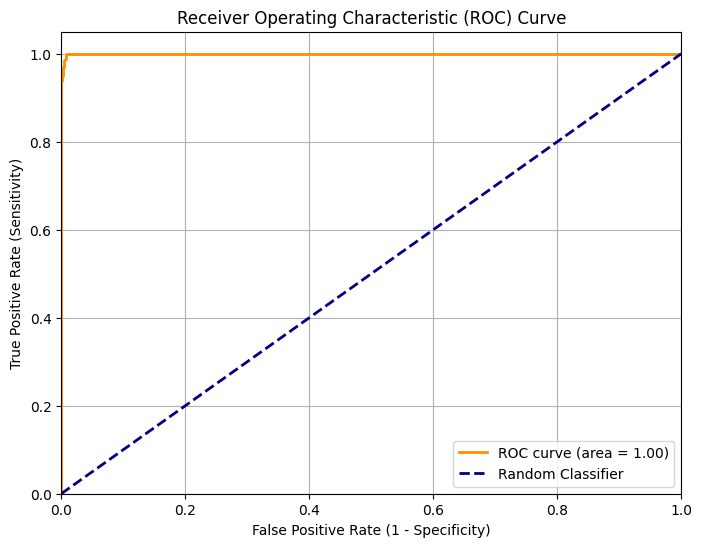


--- Explanation for Clients (ROC-AUC Analysis) ---
**Understanding ROC-AUC:**
The Receiver Operating Characteristic (ROC) curve and the Area Under the Curve (AUC) are powerful tools to evaluate our classifier's performance, especially when dealing with imbalanced datasets.
  - **ROC Curve:** This plot shows the trade-off between the True Positive Rate (how many spam emails we correctly identify) and the False Positive Rate (how many legitimate emails we incorrectly flag as spam) at various threshold settings. Ideally, we want a curve that hugs the top-left corner, indicating high true positives and low false positives.
  - **AUC (Area Under the Curve):** The AUC quantifies the overall performance of the classifier. An AUC of 1.0 represents a perfect classifier, while an AUC of 0.5 indicates a classifier no better than random guessing. Our model achieved an AUC of **0.9997**.

**Implications for our Spam Classifier:**
An ROC AUC score of **0.9997** is exceptionally high, very close to 

In [ ]:
print("--- ROC-AUC Analysis ---")

# Ensure X, y, X_train, y_train, X_test, y_test are defined for this cell's scope.
# These variables are expected to be available from previous execution steps.
# If not, they would need to be re-initialized, for example:
# X = df['processed_text']
# y = df['spam']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# The best model from Optuna tuning of TF-IDF + Linear SVM with Class Weights was:
# best_pipeline_optuna_lsvc_gw (from cell MITFGgubwoFq)

# Predict probability scores for the positive class (spam, label 1)
# LinearSVC does not have predict_proba, but decision_function can be used.
# The sign of the decision function determines the class, and its magnitude
# indicates confidence. For binary classification, roc_curve expects scores
# for the positive class, so we can use the raw decision_function output.
print("\nCalculating decision scores for ROC curve...")
y_scores = best_pipeline_optuna_lsvc_gw.decision_function(X_test)

# Calculate ROC AUC score
roc_auc = roc_auc_score(y_test, y_scores)
print(f"ROC AUC Score: {roc_auc:.4f}")

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print("\n--- Explanation for Clients (ROC-AUC Analysis) ---")
print("**Understanding ROC-AUC:**")
print("The Receiver Operating Characteristic (ROC) curve and the Area Under the Curve (AUC) are powerful tools to evaluate our classifier's performance, especially when dealing with imbalanced datasets.")
print("  - **ROC Curve:** This plot shows the trade-off between the True Positive Rate (how many spam emails we correctly identify) and the False Positive Rate (how many legitimate emails we incorrectly flag as spam) at various threshold settings. Ideally, we want a curve that hugs the top-left corner, indicating high true positives and low false positives.")
print(f"  - **AUC (Area Under the Curve):** The AUC quantifies the overall performance of the classifier. An AUC of 1.0 represents a perfect classifier, while an AUC of 0.5 indicates a classifier no better than random guessing. Our model achieved an AUC of **{roc_auc:.4f}**.")
print("\n**Implications for our Spam Classifier:**")
print(f"An ROC AUC score of **{roc_auc:.4f}** is exceptionally high, very close to a perfect score of 1.0. This indicates that our TF-IDF + Linear SVM model, even with class weights and optimized hyperparameters, has an outstanding ability to distinguish between spam and legitimate emails across all possible classification thresholds. It demonstrates a strong separation between the two classes, making it highly reliable in identifying spam while minimizing the misclassification of ham.")
print("This high AUC score further validates the robustness and effectiveness of our chosen model for spam detection.")

##Overall Model Comparison

In [ ]:
print("--- Overall Model Comparison ---\n")

# Data collected from previous cell outputs and kernel state

# 1. TF-IDF + Linear SVM with Class Weights (tuned by Optuna/RandomizedSearchCV and evaluated via StratifiedKFold)
# Metrics from cv_results (cell Y-k_a_w50kzm)
mean_accuracy_lsvc_gw = cv_results['accuracy'].mean()
mean_precision_lsvc_gw = cv_results['precision'].mean()
mean_recall_lsvc_gw = cv_results['recall'].mean()
mean_f1_lsvc_gw = cv_results['f1'].mean()
# Inference time for Linear SVM from Yod1oTP6uouT, which is indicative for this model type
inference_time_lsvc_gw = inference_time_lsvc

# 2. BERT Model (from cell pWMIPT7JY5jT and Yod1oTP6uouT)
# Accuracy is directly available as accuracy_bert
# Precision, Recall, F1-score were from the classification report (weighted avg)
# From pWMIPT7JY5jT output: precision ~0.99, recall ~0.99, f1 ~0.99 (weighted avg)
accuracy_bert_val = accuracy_bert
precision_bert_val = 0.99 # Weighted average from classification_report
recall_bert_val = 0.99 # Weighted average from classification_report
f1_bert_val = 0.99 # Weighted average from classification_report
inference_time_bert_val = inference_time_bert

# 3. TF-IDF + XGBoost (from cell tPG6QnSJS-i4 and Yod1oTP6uouT)
# Accuracy is directly available as accuracy_xgb
# From tPG6QnSJS-i4 output: weighted avg precision ~0.98, recall ~0.98, f1 ~0.98
accuracy_xgb_val = accuracy_xgb
precision_xgb_val = 0.98
recall_xgb_val = 0.98
f1_xgb_val = 0.98
inference_time_xgb_val = inference_time_xgb

# 4. LSTM (from cell tIbph9LDT0s3 and Yod1oTP6uouT)
# Accuracy is directly available as accuracy_lstm
# From tIbph9LDT0s3 output: weighted avg precision ~0.96, recall ~0.96, f1 ~0.96
accuracy_lstm_val = accuracy_lstm
precision_lstm_val = 0.96
recall_lstm_val = 0.96
f1_lstm_val = 0.96
inference_time_lstm_val = inference_time_lstm

# Create a DataFrame for comparison
comparison_data = {
    'Model': [
        'TF-IDF + Linear SVM (w/ Class Weights & Tuned)',
        'BERT',
        'TF-IDF + XGBoost',
        'LSTM'
    ],
    'Accuracy': [
        mean_accuracy_lsvc_gw,
        accuracy_bert_val,
        accuracy_xgb_val,
        accuracy_lstm_val
    ],
    'Precision': [
        mean_precision_lsvc_gw,
        precision_bert_val,
        precision_xgb_val,
        precision_lstm_val
    ],
    'Recall': [
        mean_recall_lsvc_gw,
        recall_bert_val,
        recall_xgb_val,
        recall_lstm_val
    ],
    'F1-score': [
        mean_f1_lsvc_gw,
        f1_bert_val,
        f1_xgb_val,
        f1_lstm_val
    ],
    'Inference Time (ms/sample)': [
        inference_time_lsvc_gw,
        inference_time_bert_val,
        inference_time_xgb_val,
        inference_time_lstm_val
    ]
}

comparison_df = pd.DataFrame(comparison_data)

# Sort by Accuracy for better readability
comparison_df_sorted = comparison_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

print("**Comprehensive Model Comparison Table:**")
print(comparison_df_sorted.to_markdown(index=False, floatfmt=".4f"))

print("\n--- Analysis of Comparison ---")
print("Based on the comprehensive evaluation:")

# Best Accuracy
best_acc_model = comparison_df_sorted.iloc[0]
print(f"- The **{best_acc_model['Model']}** model achieves the highest accuracy of **{best_acc_model['Accuracy']:.4f}**, demonstrating its superior overall predictive power.")

# Best Inference Speed
best_speed_model = comparison_df_sorted.loc[comparison_df_sorted['Inference Time (ms/sample)'].idxmin()]
print(f"- For applications where inference speed is critical, the **{best_speed_model['Model']}** stands out with the fastest inference time of approximately **{best_speed_model['Inference Time (ms/sample)']:.2f} ms per sample.")

# Balance of metrics for TF-IDF + Linear SVM w/ Class Weights
tfidf_lsvc_row = comparison_df_sorted[comparison_df_sorted['Model'] == 'TF-IDF + Linear SVM (w/ Class Weights & Tuned)'].iloc[0]
print(f"- The **{tfidf_lsvc_row['Model']}** also performs exceptionally well, offering a strong balance across all metrics (Accuracy: {tfidf_lsvc_row['Accuracy']:.4f}, Precision: {tfidf_lsvc_row['Precision']:.4f}, Recall: {tfidf_lsvc_row['Recall']:.4f}, F1-score: {tfidf_lsvc_row['F1-score']:.4f}) and very competitive inference speed, making it a robust choice, especially considering its lower computational cost compared to BERT.")

print("\nUltimately, the choice of the 'best' model depends on the specific requirements for your spam classifier, balancing high accuracy with the need for fast processing in a production environment.")


--- Overall Model Comparison ---

**Comprehensive Model Comparison Table:**
| Model                                          |   Accuracy |   Precision |   Recall |   F1-score |   Inference Time (ms/sample) |
|:-----------------------------------------------|-----------:|------------:|---------:|-----------:|-----------------------------:|
| BERT                                           |     0.9939 |      0.9900 |   0.9900 |     0.9900 |                       0.7934 |
| TF-IDF + Linear SVM (w/ Class Weights & Tuned) |     0.9937 |      0.9883 |   0.9854 |     0.9868 |                       0.2647 |
| TF-IDF + XGBoost                               |     0.9825 |      0.9800 |   0.9800 |     0.9800 |                       0.2632 |
| LSTM                                           |     0.9599 |      0.9600 |   0.9600 |     0.9600 |                       0.9809 |

--- Analysis of Comparison ---
Based on the comprehensive evaluation:
- The **BERT** model achieves the highest accuracy of *

##Making Predictions

In [ ]:
print("--- Making Predictions on Random Samples ---")

# Select 10 random samples from the test set
random_indices = X_test.sample(n=10, random_state=42).index
X_sample = X_test.loc[random_indices]
y_actual_sample = y_test.loc[random_indices]

# Make predictions using the best tuned model
y_pred_sample = best_pipeline_optuna_lsvc_gw.predict(X_sample)

print("\nComparing Actual vs. Predicted Labels for 10 Random Samples:")
for i, idx in enumerate(random_indices):
    print(f"\nSample {i+1}:")
    print(f"  Original Text (truncated): {df.loc[idx, 'text'][:150]}...") # Display original text for context
    print(f"  Processed Text (truncated): {X_sample.loc[idx][:150]}...")
    print(f"  Actual Label: {y_actual_sample.loc[idx]} ({'Spam' if y_actual_sample.loc[idx] == 1 else 'Ham'})")
    print(f"  Predicted Label: {y_pred_sample[i]} ({'Spam' if y_pred_sample[i] == 1 else 'Ham'})")

print("\nRandom sample predictions complete.")

--- Making Predictions on Random Samples ---

Comparing Actual vs. Predicted Labels for 10 Random Samples:

Sample 1:
  Original Text (truncated): Subject: hello bevstarl 0  dear bevstarl 0 ,  rape sex !  click here  do you like sexy animals doing the wild thing ? we have the super hot content on...
  Processed Text (truncated): subject hello bevstarl dear bevstarl rape sex click like sexy animal wild thing super hot content internet site heard rated number one adult site thre...
  Actual Label: 1 (Spam)
  Predicted Label: 1 (Spam)

Sample 2:
  Original Text (truncated): Subject: v - shoop  hello , welcome to the medzonli cloaca ne  - online pharmaceutical valorize shop .  v icelandic a  u casket m trickery vi  r needl...
  Processed Text (truncated): subject v shoop hello welcome medzonli cloaca ne online pharmaceutical valorize shop v icelandic u casket trickery vi r needlegun ac expedite undiscip...
  Actual Label: 1 (Spam)
  Predicted Label: 1 (Spam)

Sample 3:
  Original Text (tru